# Init

In [1]:
# Setup
import yaml
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import scipy.stats as stats

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

In [2]:
from src.feedbackqa.regression import FeedbackQARegressionRunner
from src.feedbackqa.diagnostics import collect_all_diagnostics, extract_diagnostic_table, overview

from src.general_analysis.engine import AnalysisEnvironment
from src.general_analysis.reliability import ReliabilityAnalyzer

from src.prompt_manager import PromptManager

from src.utils import interactive_dataframe_selector, interactive_regression_results_selector, interactive_plot_viewer

In [3]:
import pandas as pd


def chain_print(self):
    # .to_string() ensures you get the full output without (...) truncation
    print(self.to_string())
    return self


pd.Series.print = chain_print
pd.DataFrame.print = chain_print

# Load data

In [ ]:
env = AnalysisEnvironment(
    active_analysis='mcgill_qa_feedback', sandbox_mode=False)

# Load everything
# models_to_include: ['Qwen-Qwen3.5-4B', 'meta-llama-Llama-3.2-3B-Instruct']
final_df, og_df = env.load_data(use_cache=True, force_refresh=False)
pm, prompt_map = env.load_prompts()


prompt_hash_map = {
    key: item.metadata['description']
    for key, item in pm.suites.items()
}

Loading files for analysis McGill Feedback Analysis
⚡ Loading cached DataFrame from C:\Users\Wouter Barter\Documents\AI_thesis\results\MCGILL_QA_FEEDBACK\MCGILL_QA_FEEDBACK_analysis_ready.pkl...
PromptManager initialized with folder: ..\prompts\PromptSuites\MCGILL_QA_FEEDBACK
Scanning 6 suites from ..\prompts\PromptSuites\MCGILL_QA_FEEDBACK...
Loaded 6 PromptSuites


# Data Pre-processing

## Human readable cols

In [5]:
# Human readable prompt names

prompt_map_clean = {'f926cb88b5c8': 'Holistic Naive',
                    'f1ea5fbc4957': 'Holistic Informed', '83fb9645af53': 'Formative'}
final_df['prompt_name'] = final_df['prompt_id'].map(prompt_map_clean)

# Analysis group concatenation
final_df['analysis_group'] = final_df['model_name'] + \
    "_" + final_df['prompt_id']
final_df['analysis_group_full'] = final_df['model_name'] + "_" + \
    final_df['prompt_id'] + "_" + final_df['dimension_name']
final_df['analysis_group_named'] = final_df['model_name'] + \
    "_" + final_df['prompt_name'] + "_" + final_df['prompt_id']


# Human readable model col
model_map_clean = {
    'google/gemma-4-E2B-it': "Gemma 4",
    'meta-llama/Llama-3.2-3B-Instruct': "Llama 3.2",
    'Qwen/Qwen3-4B-Instruct-2507': "Qwen 3",
    'Qwen/Qwen3.5-4B': "Qwen 3.5"
}
final_df['model_name_clean'] = final_df['model_name'].map(model_map_clean)

# Human readable dimension col
dim_map_clean = {
    'qa_pair_topical_alignment': 'Topical Alignment',
    'qa_pair_information_coverage': 'Information Coverage',
    'qa_pair_topical_concentration': 'Topical Concentration',
    'qa_pair_communicative_clarity': 'Communicative Clarity',
    'qa_pair_overall_answer_quality': 'Overall Quality'
}
final_df['dimension_name_clean'] = final_df['dimension_name'].map(
    dim_map_clean)

final_df.loc[final_df['prompt_id'] == 'f1ea5fbc4957',
             'dimension_name_clean'] = 'Overall Quality (Informed)'
final_df.loc[final_df['prompt_id'] == 'f926cb88b5c8',
             'dimension_name_clean'] = 'Overall Quality (Naive)'


# Human readable analysis group/ experimental group
final_df['analysis_group_full_clean'] = final_df['model_name_clean'] + \
    ": " + final_df['dimension_name_clean'] + \
    "(" + final_df['prompt_name'] + ")"

## Extra features

In [6]:
# Input length
final_df['raw_input_length'] = final_df['question'].apply(
    len) + final_df['answer'].apply(len)

# Fill NaNs to prevent errors, split by whitespace, and count the list length
q_words = final_df['question'].fillna('').str.split().str.len()
a_words = final_df['answer'].fillna('').str.split().str.len()

final_df['question_word_count'] = q_words
final_df['answer_word_count'] = a_words
final_df['raw_input_word_count'] = q_words + a_words

final_df['log_raw_input_word_count'] = np.log1p(
    final_df['raw_input_word_count'])


final_df['length_bucket'] = pd.qcut(final_df['raw_input_word_count'], q=4,
                                    labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

final_df['answer_length_bucket'] = pd.qcut(final_df['answer_word_count'], q=4,
                                           labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

# General EDA

In [7]:
# plot_order = [
#     'Holistic Naive',
#     'Holistic Informed',
#     'Formative\nTopical Alignment',
#     'Formative\nInformation Coverage',
#     'Formative\nTopical Concentration',
#     'Formative\nCommunicative Clarity'
# ]

plot_order = list(dim_map_clean.values())


prompt_order = ['Holistic Naive', 'Holistic Informed', 'Formative']

## Distribrution across rating scale

In [8]:
combined_scores = pd.concat(
    [og_df['score_1'], og_df['score_2']], ignore_index=True)

In [9]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt


# # Assuming your dataframe is melted/long-format with 'rater_id' and 'score'
# # If it's not, you should melt it first to make this easy:

# combined_scores = pd.concat(
#     [og_df['score_1'], og_df['score_2']], ignore_index=True)


# combined_scores_z = (combined_scores - combined_scores.mean()
#                      ) / combined_scores.std()


# # Assuming og_df is already defined in your environment
# # Combine the two score columns into a single Series

# # Create the figure and plot
# plt.figure(figsize=(8, 6))
# sns.violinplot(y=combined_scores, color="skyblue", cut=0)

# # Add labels and title
# plt.title("Combined Distribution of Score 1 and Score 2")
# plt.ylabel("Rating")

# # Show the plot
# plt.show()

In [10]:
og_df

,question,passage,feedback,rating,domain,source_file,review_1,explanation_1,review_2,explanation_2,score_1,score_2,answer,input_id
0,How do I get help finding a job?,"{'passage_id': 140, 'reference': {'page_title'...",[Has a link to detailed information about gove...,"[Excellent, Could be Improved]",Australia,train,Excellent,Has a link to detailed information about gover...,Could be Improved,"This answer provides a link for job searches, ...",4,2,If you are a current job seeker or participant...,eff9e000675931f5
1,How do I get help finding a job?,"{'passage_id': 139, 'reference': {'page_title'...","[A link to a job search website is included, a...","[Excellent, Excellent]",Australia,train,Excellent,"A link to a job search website is included, as...",Excellent,"Includes a link to a Jobs Hub page, which is b...",4,4,In this rapidly changing jobs market the Austr...,c8be913323f10444
2,How do I get help finding a job?,"{'passage_id': 126, 'reference': {'page_title'...",[Talks about tax credits for businesses that h...,"[Bad, Acceptable]",Australia,train,Bad,Talks about tax credits for businesses that hi...,Acceptable,"This answer discusses the Employment Fund, whi...",1,3,To further assist job seekers to prepare for a...,31effc925bc04105
3,If I am in Australia on a worker holiday marke...,"{'passage_id': 581, 'reference': {'page_title'...","[Answer is about Working Holiday Makers, but d...","[Could be Improved, Acceptable]",Australia,train,Could be Improved,"Answer is about Working Holiday Makers, but do...",Acceptable,Answer is rather cut and dry but is also a lit...,2,3,No. Existing arrangements for specified work w...,610d0764ed04054d
4,If I am in Australia on a worker holiday marke...,"{'passage_id': 577, 'reference': {'page_title'...",[Discusses pandemic visas. Doesn't mention the...,"[Bad, Could be Improved]",Australia,train,Bad,Discusses pandemic visas. Doesn't mention the ...,Could be Improved,This answer is very vague and does not answer ...,1,2,The COVID-19 Pandemic event visa can only be g...,033e9fcef5d75297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1990,How can I access contraception during the COVI...,"{'passage_id': 72, 'reference': {'page_title':...",[This talks about access to contraceptives but...,"[Could be Improved, Bad, Bad]",WHO,test,Could be Improved,This talks about access to contraceptives but ...,Bad,Off topic does not give advice on how to get i...,2,1,"Yes. It may be difficult however, to access al...",81871fba8d69180f
1991,Is it ok to change my contraception method now?,"{'passage_id': 72, 'reference': {'page_title':...",[This answer relates to the question and thus ...,"[Excellent, Could be Improved, Acceptable]",WHO,test,Excellent,This answer relates to the question and thus i...,Could be Improved,This answers the questions but suggest that it...,4,2,"Yes. It may be difficult however, to access al...",7e5210ae0192db9a
1992,Is it a requirement for suspected or confirmed...,"{'passage_id': 105, 'reference': {'page_title'...",[This answer does not relate to the original q...,"[Bad, Bad, Bad]",WHO,test,Bad,This answer does not relate to the original qu...,Bad,The answer doesn't discuss using separate hosp...,1,1,Health care workers collecting NP and OP swab ...,3530d10830c4f7aa
1993,How can food producers make sure the water the...,"{'passage_id': 209, 'reference': {'page_title'...",[There is not a lot of information in this ans...,"[Could be Improved, Could be Improved, Accepta...",WHO,test,Could be Improved,There is not a lot of information in this answ...,Could be Improved,This answer is OK with much more deeper explan...,2,2,There is no evidence that COVID-19 is transmit...,ed4075db7ce90bbd


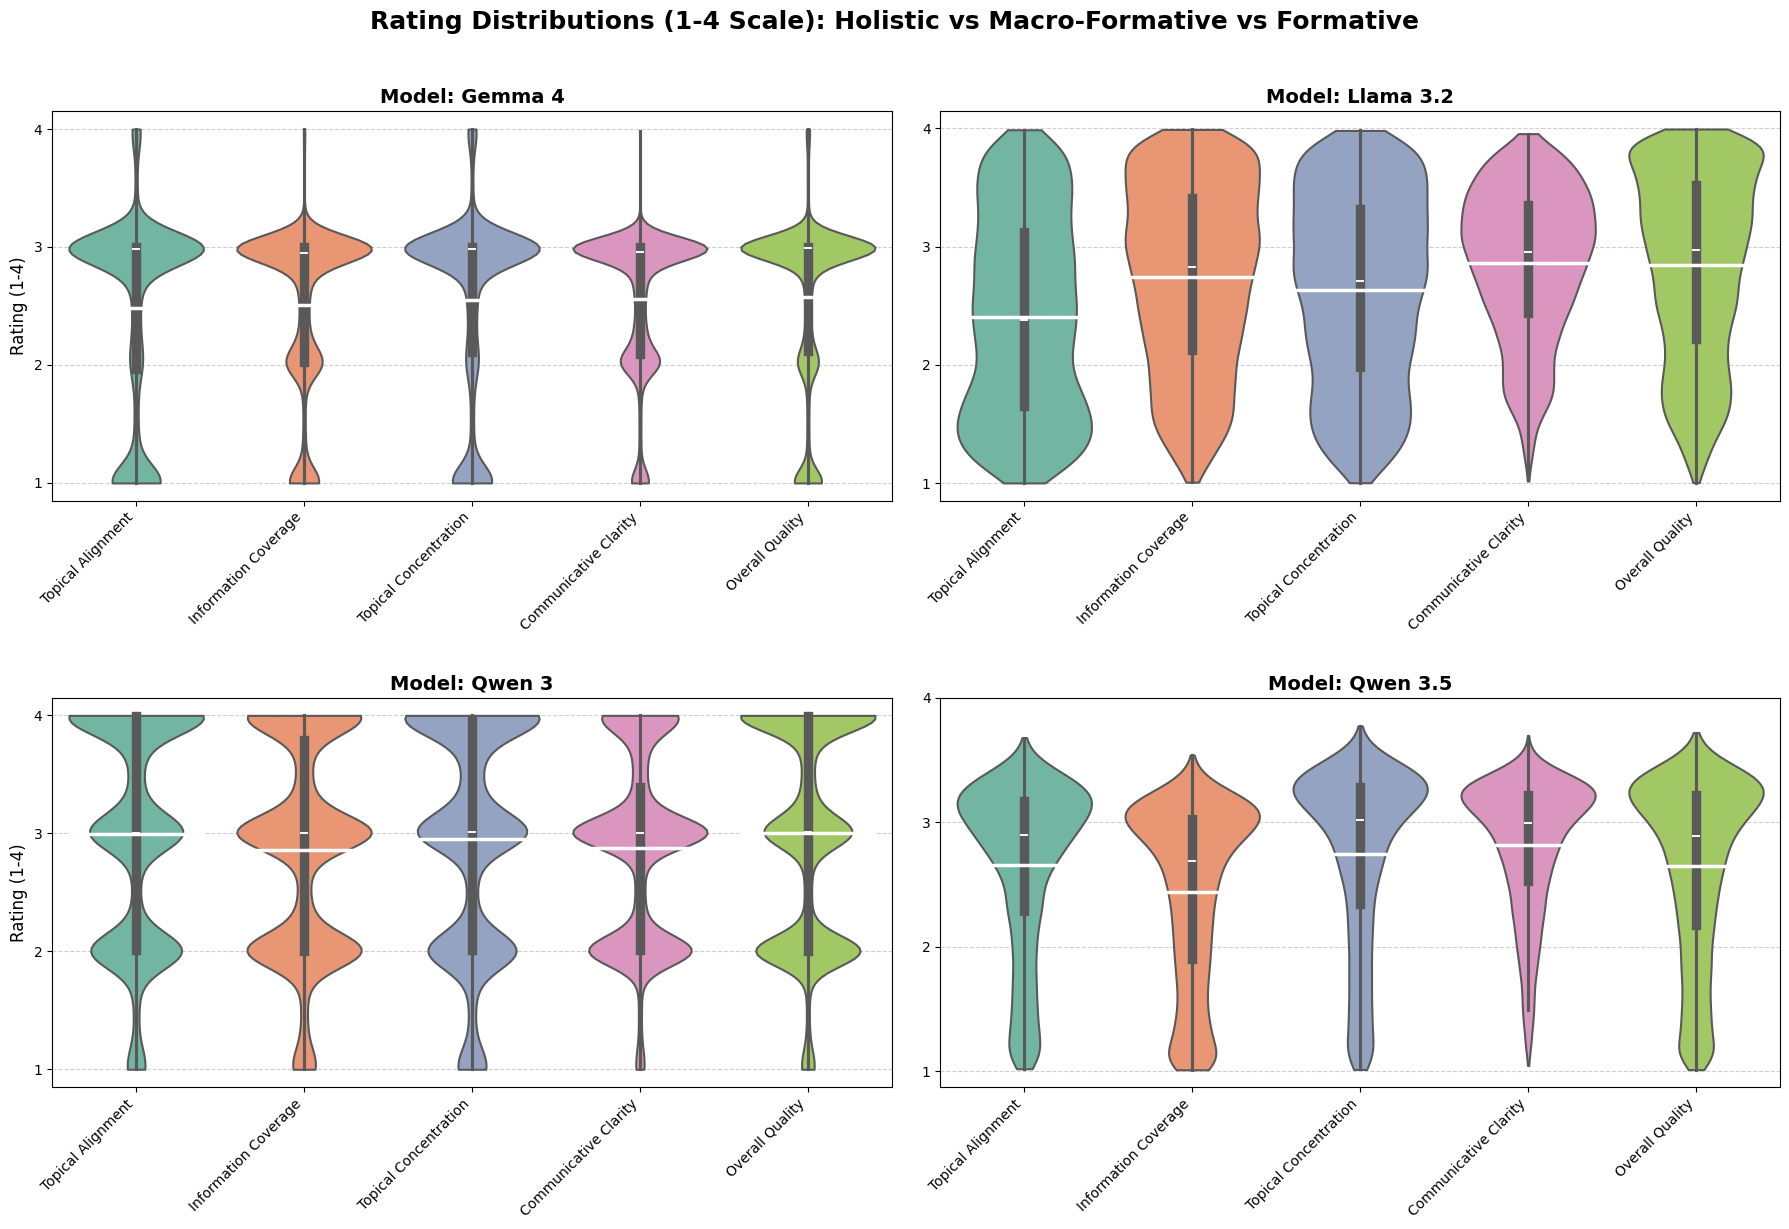

In [11]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (1, 4)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, dim_map_clean=dim_map_clean, score_col='mean_rating', rating_range=rating_range)

## Multi-modality

In [12]:
# Import the functions from your shared file
from src.general_analysis.visualisations import append_multimodality_flags, generate_multimodality_report

# 1. Process the dataframe (works for any dataset as long as you pass the right column)
final_df = append_multimodality_flags(final_df, logits_col='sorted_logits')

### Standard multi-modality

In [13]:
# 2. Generate and display the table
styled_stats = generate_multimodality_report(
    final_df, group_col='analysis_group_named')
display(styled_stats)

,Failure_Rate,Std_Dev,Total_Evaluations
analysis_group_named,,,
Qwen/Qwen3.5-4B_Formative_83fb9645af53,56.78%,0.4954,"36,252"
Qwen/Qwen3.5-4B_Holistic Naive_f926cb88b5c8,39.03%,0.4878,"9,063"
meta-llama/Llama-3.2-3B-Instruct_Formative_83fb9645af53,31.58%,0.4648,"36,252"
meta-llama/Llama-3.2-3B-Instruct_Holistic Informed_f1ea5fbc4957,30.02%,0.4584,"9,063"
Qwen/Qwen3.5-4B_Holistic Informed_f1ea5fbc4957,29.86%,0.4577,"9,063"
meta-llama/Llama-3.2-3B-Instruct_Holistic Naive_f926cb88b5c8,26.53%,0.4415,"9,063"
Qwen/Qwen3-4B-Instruct-2507_Formative_83fb9645af53,16.22%,0.3686,"36,252"
Qwen/Qwen3-4B-Instruct-2507_Holistic Informed_f1ea5fbc4957,13.41%,0.3407,"9,063"
Qwen/Qwen3-4B-Instruct-2507_Holistic Naive_f926cb88b5c8,11.01%,0.3131,"9,063"


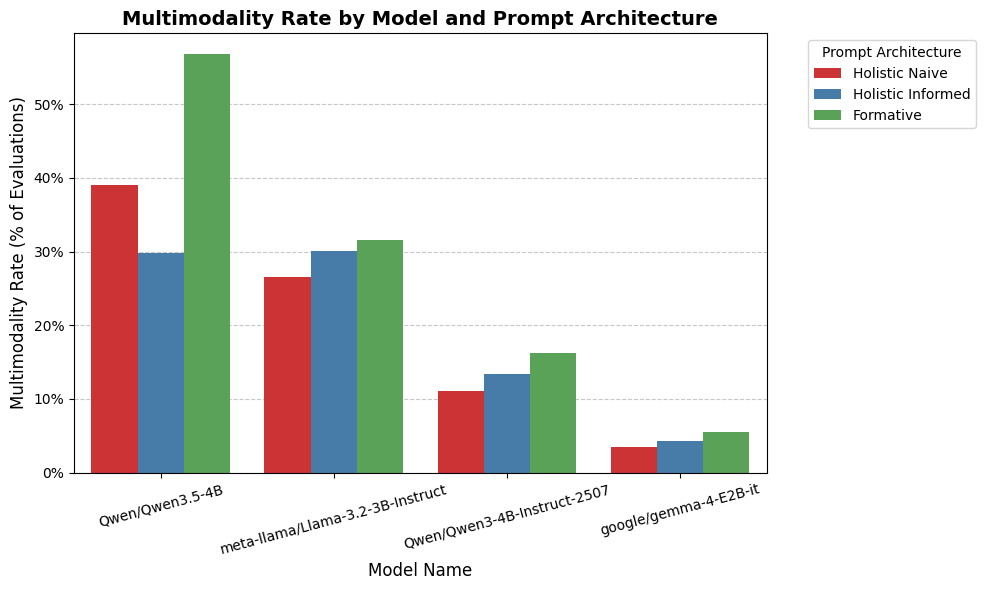

<Axes: title={'center': 'Multimodality Rate by Model and Prompt Architecture'}, xlabel='Model Name', ylabel='Multimodality Rate (% of Evaluations)'>

In [14]:
from src.general_analysis.visualisations import plot_multimodality_rates

# Pass the raw multimodal_stats variable we generated in the previous step
# (Before applying the .style.format() chaining)
plot_multimodality_rates(styled_stats.data, prompt_order=prompt_order)

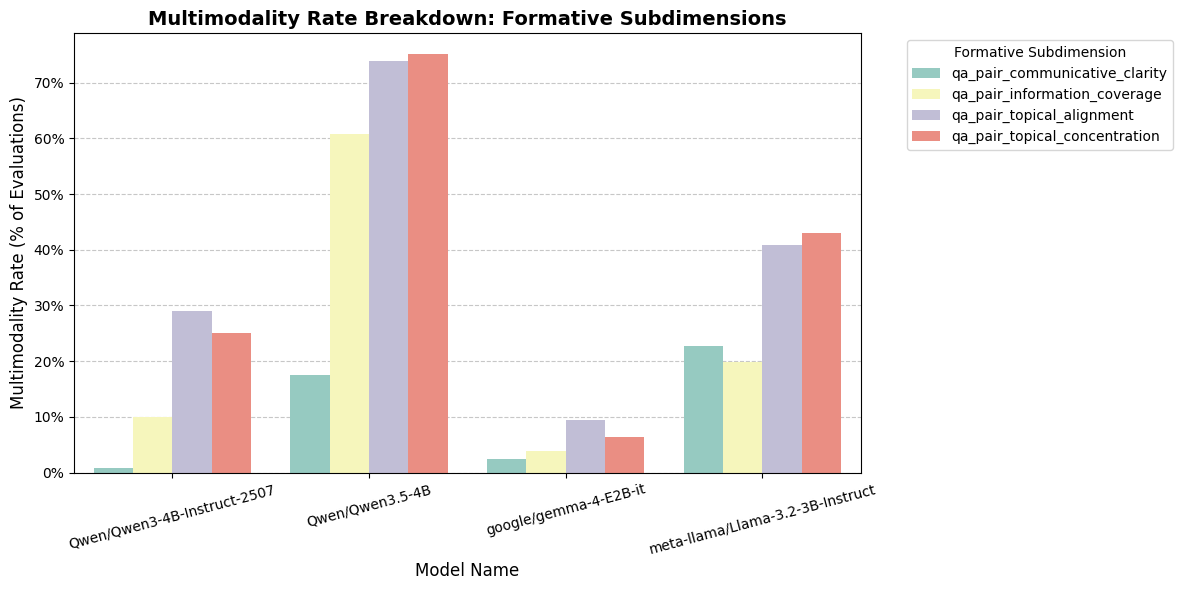

<Axes: title={'center': 'Multimodality Rate Breakdown: Formative Subdimensions'}, xlabel='Model Name', ylabel='Multimodality Rate (% of Evaluations)'>

In [15]:
from src.general_analysis.visualisations import plot_formative_multimodality_breakdown

# Render the subdimension drill-down
plot_formative_multimodality_breakdown(final_df)

# Or save it directly
# plot_formative_multimodality_breakdown(final_df, save_path='figures/formative_multimodality_breakdown.png')

### Multi-modal severity metric

In [16]:
from src.general_analysis.visualisations import append_multimodality_severity, generate_multimodal_severity_report
final_df = append_multimodality_severity(final_df, logits_col='sorted_logits')
generate_multimodal_severity_report(final_df)

,Mean_Severity,Max_Severity,Total_Evaluations
analysis_group_named,,,
Qwen/Qwen3.5-4B_Formative_83fb9645af53,10.18%,57.91%,"36,252"
meta-llama/Llama-3.2-3B-Instruct_Formative_83fb9645af53,7.42%,84.90%,"36,252"
Qwen/Qwen3.5-4B_Holistic Naive_f926cb88b5c8,5.85%,57.81%,"9,063"
meta-llama/Llama-3.2-3B-Instruct_Holistic Informed_f1ea5fbc4957,4.50%,76.56%,"9,063"
Qwen/Qwen3.5-4B_Holistic Informed_f1ea5fbc4957,4.18%,52.24%,"9,063"
meta-llama/Llama-3.2-3B-Instruct_Holistic Naive_f926cb88b5c8,3.06%,65.14%,"9,063"
google/gemma-4-E2B-it_Formative_83fb9645af53,0.13%,72.35%,"36,252"
google/gemma-4-E2B-it_Holistic Informed_f1ea5fbc4957,0.08%,57.47%,"9,063"
google/gemma-4-E2B-it_Holistic Naive_f926cb88b5c8,0.04%,61.31%,"9,063"


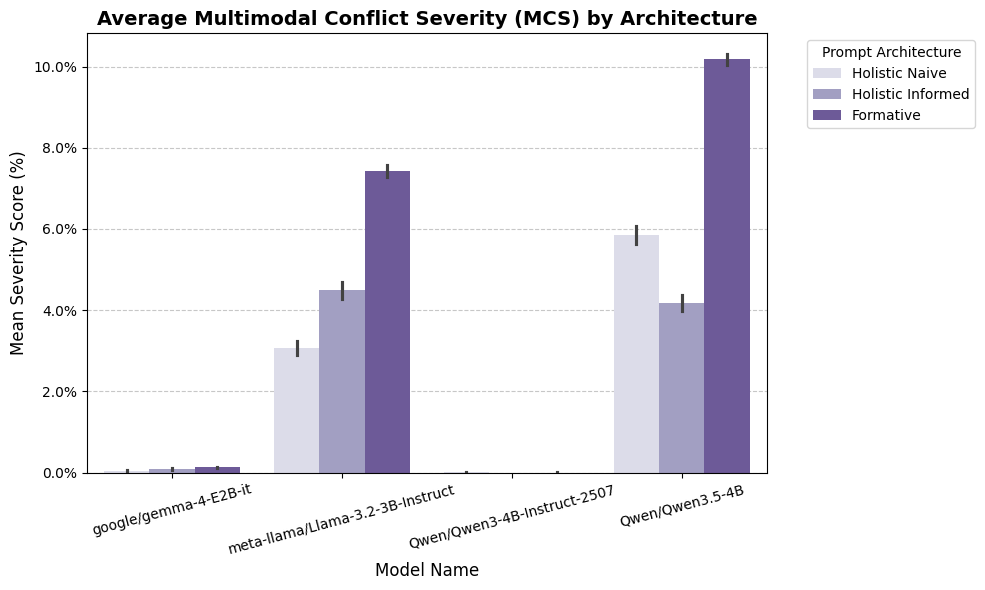

<Axes: title={'center': 'Average Multimodal Conflict Severity (MCS) by Architecture'}, xlabel='Model Name', ylabel='Mean Severity Score (%)'>

In [17]:
from src.general_analysis.visualisations import plot_severity_bar_chart
plot_severity_bar_chart(final_df)

## Disagreement: Multi-modality & Entropy

In [18]:
og_df['human_disagreement'] = abs(og_df.score_1 - og_df.score_2)
og_df.human_disagreement.value_counts().print()

human_disagreement
0    4301
1    2965
2    1240
3     559


human_disagreement
0    4301
1    2965
2    1240
3     559
Name: count, dtype: int64

### Entropy & disagremeent

C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:1657: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:1657: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


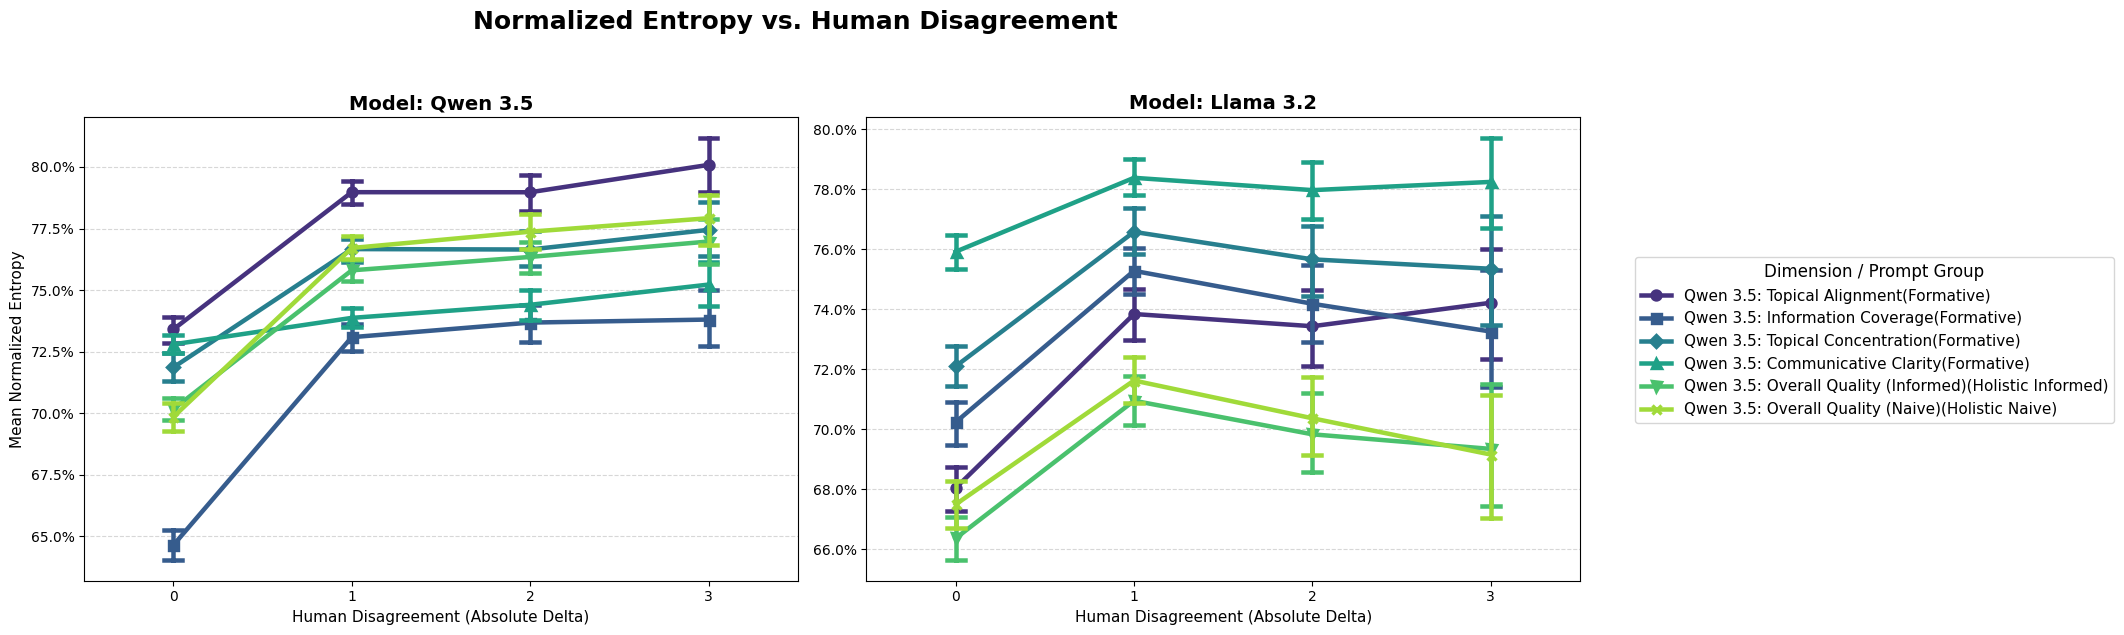

In [19]:
from src.general_analysis.visualisations import plot_variable_grid

plot_variable_grid(final_df, x_var='human_disagreement',
                   y_var='normalized_entropy', models=['Qwen 3.5', 'Llama 3.2'])

In [20]:
# Predicting disagreement from entropy
runner_entropy = FeedbackQARegressionRunner(
    prompt_hash_map=prompt_hash_map,
    dep_var="score_1_score_2_disagreement",  # computed automatically
    llm_prediction_col="normalized_entropy",  # entropy as the main predictor
    include_entropy=False,                   # already the predictor, don't double-add
    mode="disagreement",
)
runner_entropy.run_regression(final_df)

✓ Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23796.93
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23776.61
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=9063 | AIC=23779.16
✓ Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23469.42
✓ Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23539.96
✓ Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=9063 | AIC=23495.80
✓ google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23814.72
✓ google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23831.95
✓ google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1

{'Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2358fe04690>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342dd1b9d0>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x23582722110>,
 'Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2358fe04450>,
 'Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2358063fe50>,
 'Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_mo

In [21]:
runner_entropy.summarize()

,label,mode,nobs,r_squared,adj_r_squared,aic,bic,condition_number
3,"Qwen/Qwen3.5-4B_Formative v3, scale 4, system ...",disagreement,9063.0,0.040398,0.039974,23469.420229,23504.980006,30.627706
5,"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, sy...",disagreement,9063.0,0.036963,0.036857,23495.799855,23510.023766,9.490985
4,"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4,...",disagreement,9063.0,0.032260,0.032153,23539.959168,23554.183079,10.633926
9,"meta-llama/Llama-3.2-3B-Instruct_Formative v3,...",disagreement,9063.0,0.010082,0.009645,23751.307761,23786.867538,26.364195
1,Qwen/Qwen3-4B-Instruct-2507_Holistic informed ...,disagreement,9063.0,0.006657,0.006547,23776.612712,23790.836623,6.601554
2,"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2,...",disagreement,9063.0,0.006378,0.006268,23779.159111,23793.383022,6.433427
0,"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scal...",disagreement,9063.0,0.005086,0.004647,23796.934087,23832.493864,8.002812
10,meta-llama/Llama-3.2-3B-Instruct_Holistic info...,disagreement,9063.0,0.003508,0.003398,23805.296887,23819.520798,6.091774
6,"google/gemma-4-E2B-it_Formative v3, scale 4, s...",disagreement,9063.0,0.003132,0.002692,23814.717989,23850.277766,8.359326
11,meta-llama/Llama-3.2-3B-Instruct_Holistic naiv...,disagreement,9063.0,0.002119,0.002008,23817.926428,23832.150339,6.262566


In [22]:
interactive_regression_results_selector(runner_entropy.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3-4B-Instruct-2507_For…

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     score_1_score_2_disagreement   R-squared:                       0.005
Model:                                      OLS   Adj. R-squared:                  0.005
Method:                           Least Squares   F-statistic:                     11.58
Date:                          Wed, 13 May 2026   Prob (F-statistic):           2.25e-09
Time:                                  02:04:03   Log-Likelihood:                -11893.
No. Observations:                          9063   AIC:                         2.380e+04
Df Residuals:                              9058   BIC:                         2.383e+04
Df Model:                                     4                                         
Covariance Type:                      nonrobust                                         
====================================================================================================================
                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
const                                                0.7161      0.015     46.946      0.000       0.686       0.746
normalized_entropy_qa_pair_communicative_clarity     0.0382      0.059      0.642      0.521      -0.078       0.155
normalized_entropy_qa_pair_information_coverage      0.0680      0.061      1.108      0.268      -0.052       0.188
normalized_entropy_qa_pair_topical_alignment         0.2298      0.065      3.544      0.000       0.103       0.357
normalized_entropy_qa_pair_topical_concentration     0.2283      0.062      3.667      0.000       0.106       0.350
==============================================================================
Omnibus:                      971.057   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1322.314
Skew:                           0.936   Prob(JB):                    7.30e-288
Kurtosis:                       2.982   Cond. No.                         8.00
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Multimodality & disagremeent

C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:1657: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:1657: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


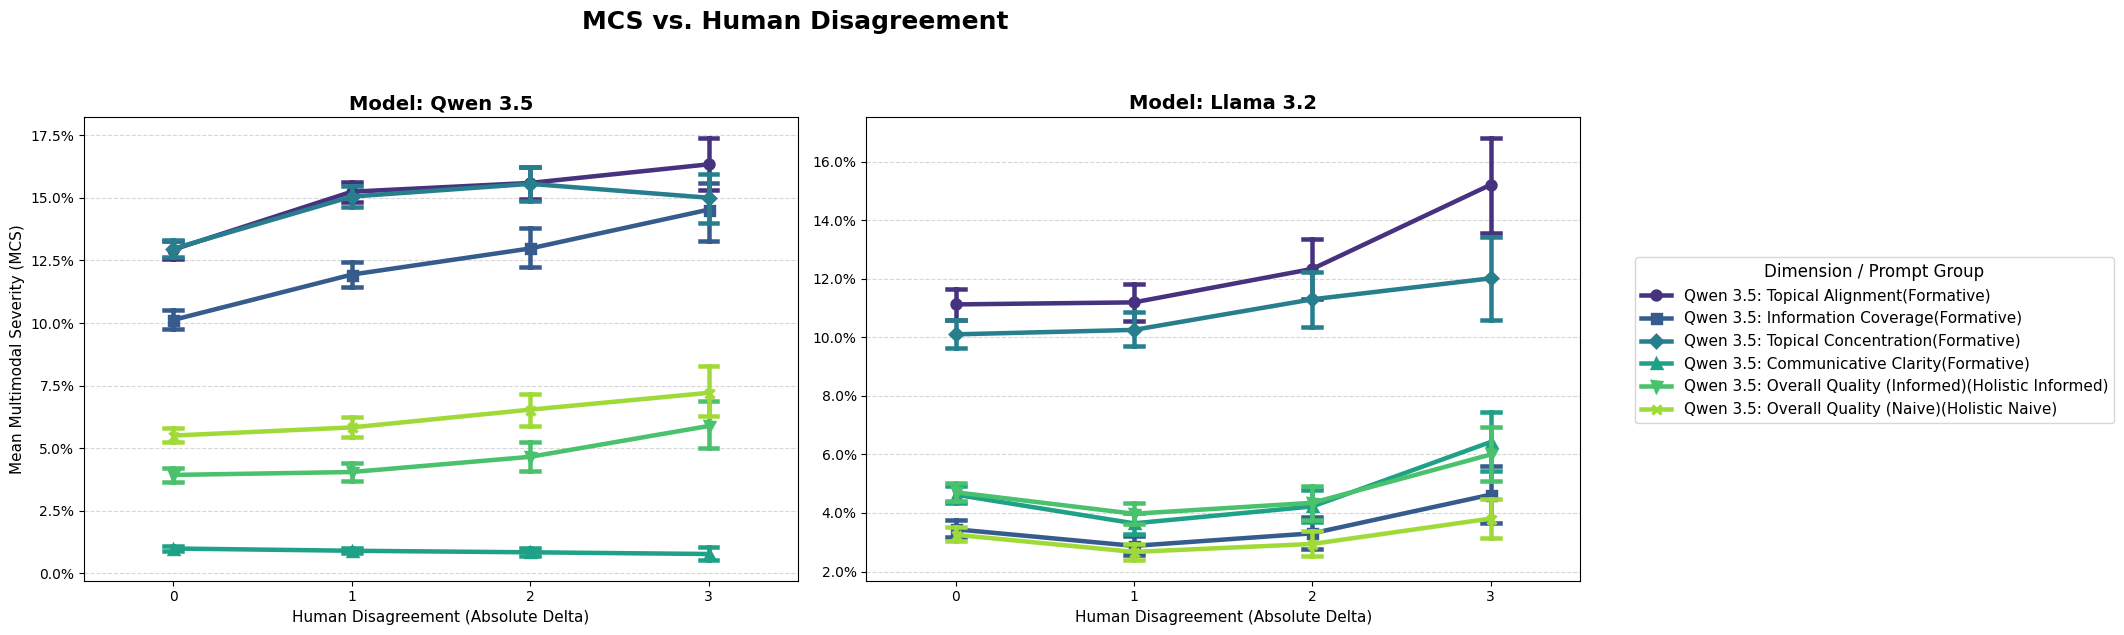

In [23]:
plot_variable_grid(final_df, x_var='human_disagreement',
                   y_var='multimodal_severity_score', models=['Qwen 3.5', 'Llama 3.2'])

b0a822ee80e934b2 is the perfect example of why the multimodality severity score is valuable. The judges disagree, because the text did actually contain conflicting information. As we see by the plot, the multimodality increases by about 50% for texts that are maximal disagreement.


In [24]:
# Predicting disagreement from entropy
runner_multimodality = FeedbackQARegressionRunner(
    prompt_hash_map=prompt_hash_map,
    dep_var="score_1_score_2_disagreement",  # computed automatically
    llm_prediction_col="multimodal_severity_score",  # entropy as the main predictor
    include_entropy=False,                   # already the predictor, don't double-add
    mode="disagreement",
)
runner_multimodality.run_regression(final_df)

✓ Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23837.20
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23837.12
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=9063 | AIC=23836.38
✓ Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23702.36
✓ Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23817.80
✓ Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=9063 | AIC=23818.97
✓ google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23834.10
✓ google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23835.91
✓ google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1

{'Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342dda6a50>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2358b4df590>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x234214cc110>,
 'Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342d7cf290>,
 'Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342d80e2d0>,
 'Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_mo

In [25]:
interactive_regression_results_selector(
    runner_multimodality.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3-4B-Instruct-2507_For…

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     score_1_score_2_disagreement   R-squared:                       0.001
Model:                                      OLS   Adj. R-squared:                  0.000
Method:                           Least Squares   F-statistic:                     1.486
Date:                          Wed, 13 May 2026   Prob (F-statistic):              0.204
Time:                                  02:04:06   Log-Likelihood:                -11914.
No. Observations:                          9063   AIC:                         2.384e+04
Df Residuals:                              9058   BIC:                         2.387e+04
Df Model:                                     4                                         
Covariance Type:                      nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
const                                                       0.7914      0.010     80.827      0.000       0.772       0.811
multimodal_severity_score_qa_pair_communicative_clarity -2.095e+05   8.43e+05     -0.249      0.804   -1.86e+06    1.44e+06
multimodal_severity_score_qa_pair_information_coverage      2.7322     11.807      0.231      0.817     -20.413      25.877
multimodal_severity_score_qa_pair_topical_alignment     -4.838e+04   2.18e+04     -2.217      0.027   -9.12e+04   -5601.049
multimodal_severity_score_qa_pair_topical_concentration    -4.9281      5.472     -0.901      0.368     -15.655       5.799
==============================================================================
Omnibus:                      976.992   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1332.763
Skew:                           0.939   Prob(JB):                    3.93e-290
Kurtosis:                       2.974   Cond. No.                     8.91e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.14e-12. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

In [26]:
# diagnostics_mm = collect_all_diagnostics(runner_multimodality)
# diagnostics_entr = collect_all_diagnostics(runner_entropy)

# ov_mm = overview(diagnostics_mm)
# ov_entr = overview(diagnostics_entr)

# interactive_dataframe_selector(ov_entr)

# interactive_dataframe_selector(ov_mm)

# ov_entr['metrics'].to_csv('entropy_disagreement_model.csv')
# ov_mm['metrics'].to_csv('multimodality_disagreement_model.csv')

## Verbosity bias (relationship between input length and rating)

### Ceiling effect

In [27]:
from src.general_analysis.visualisations import plot_verbosity_grid

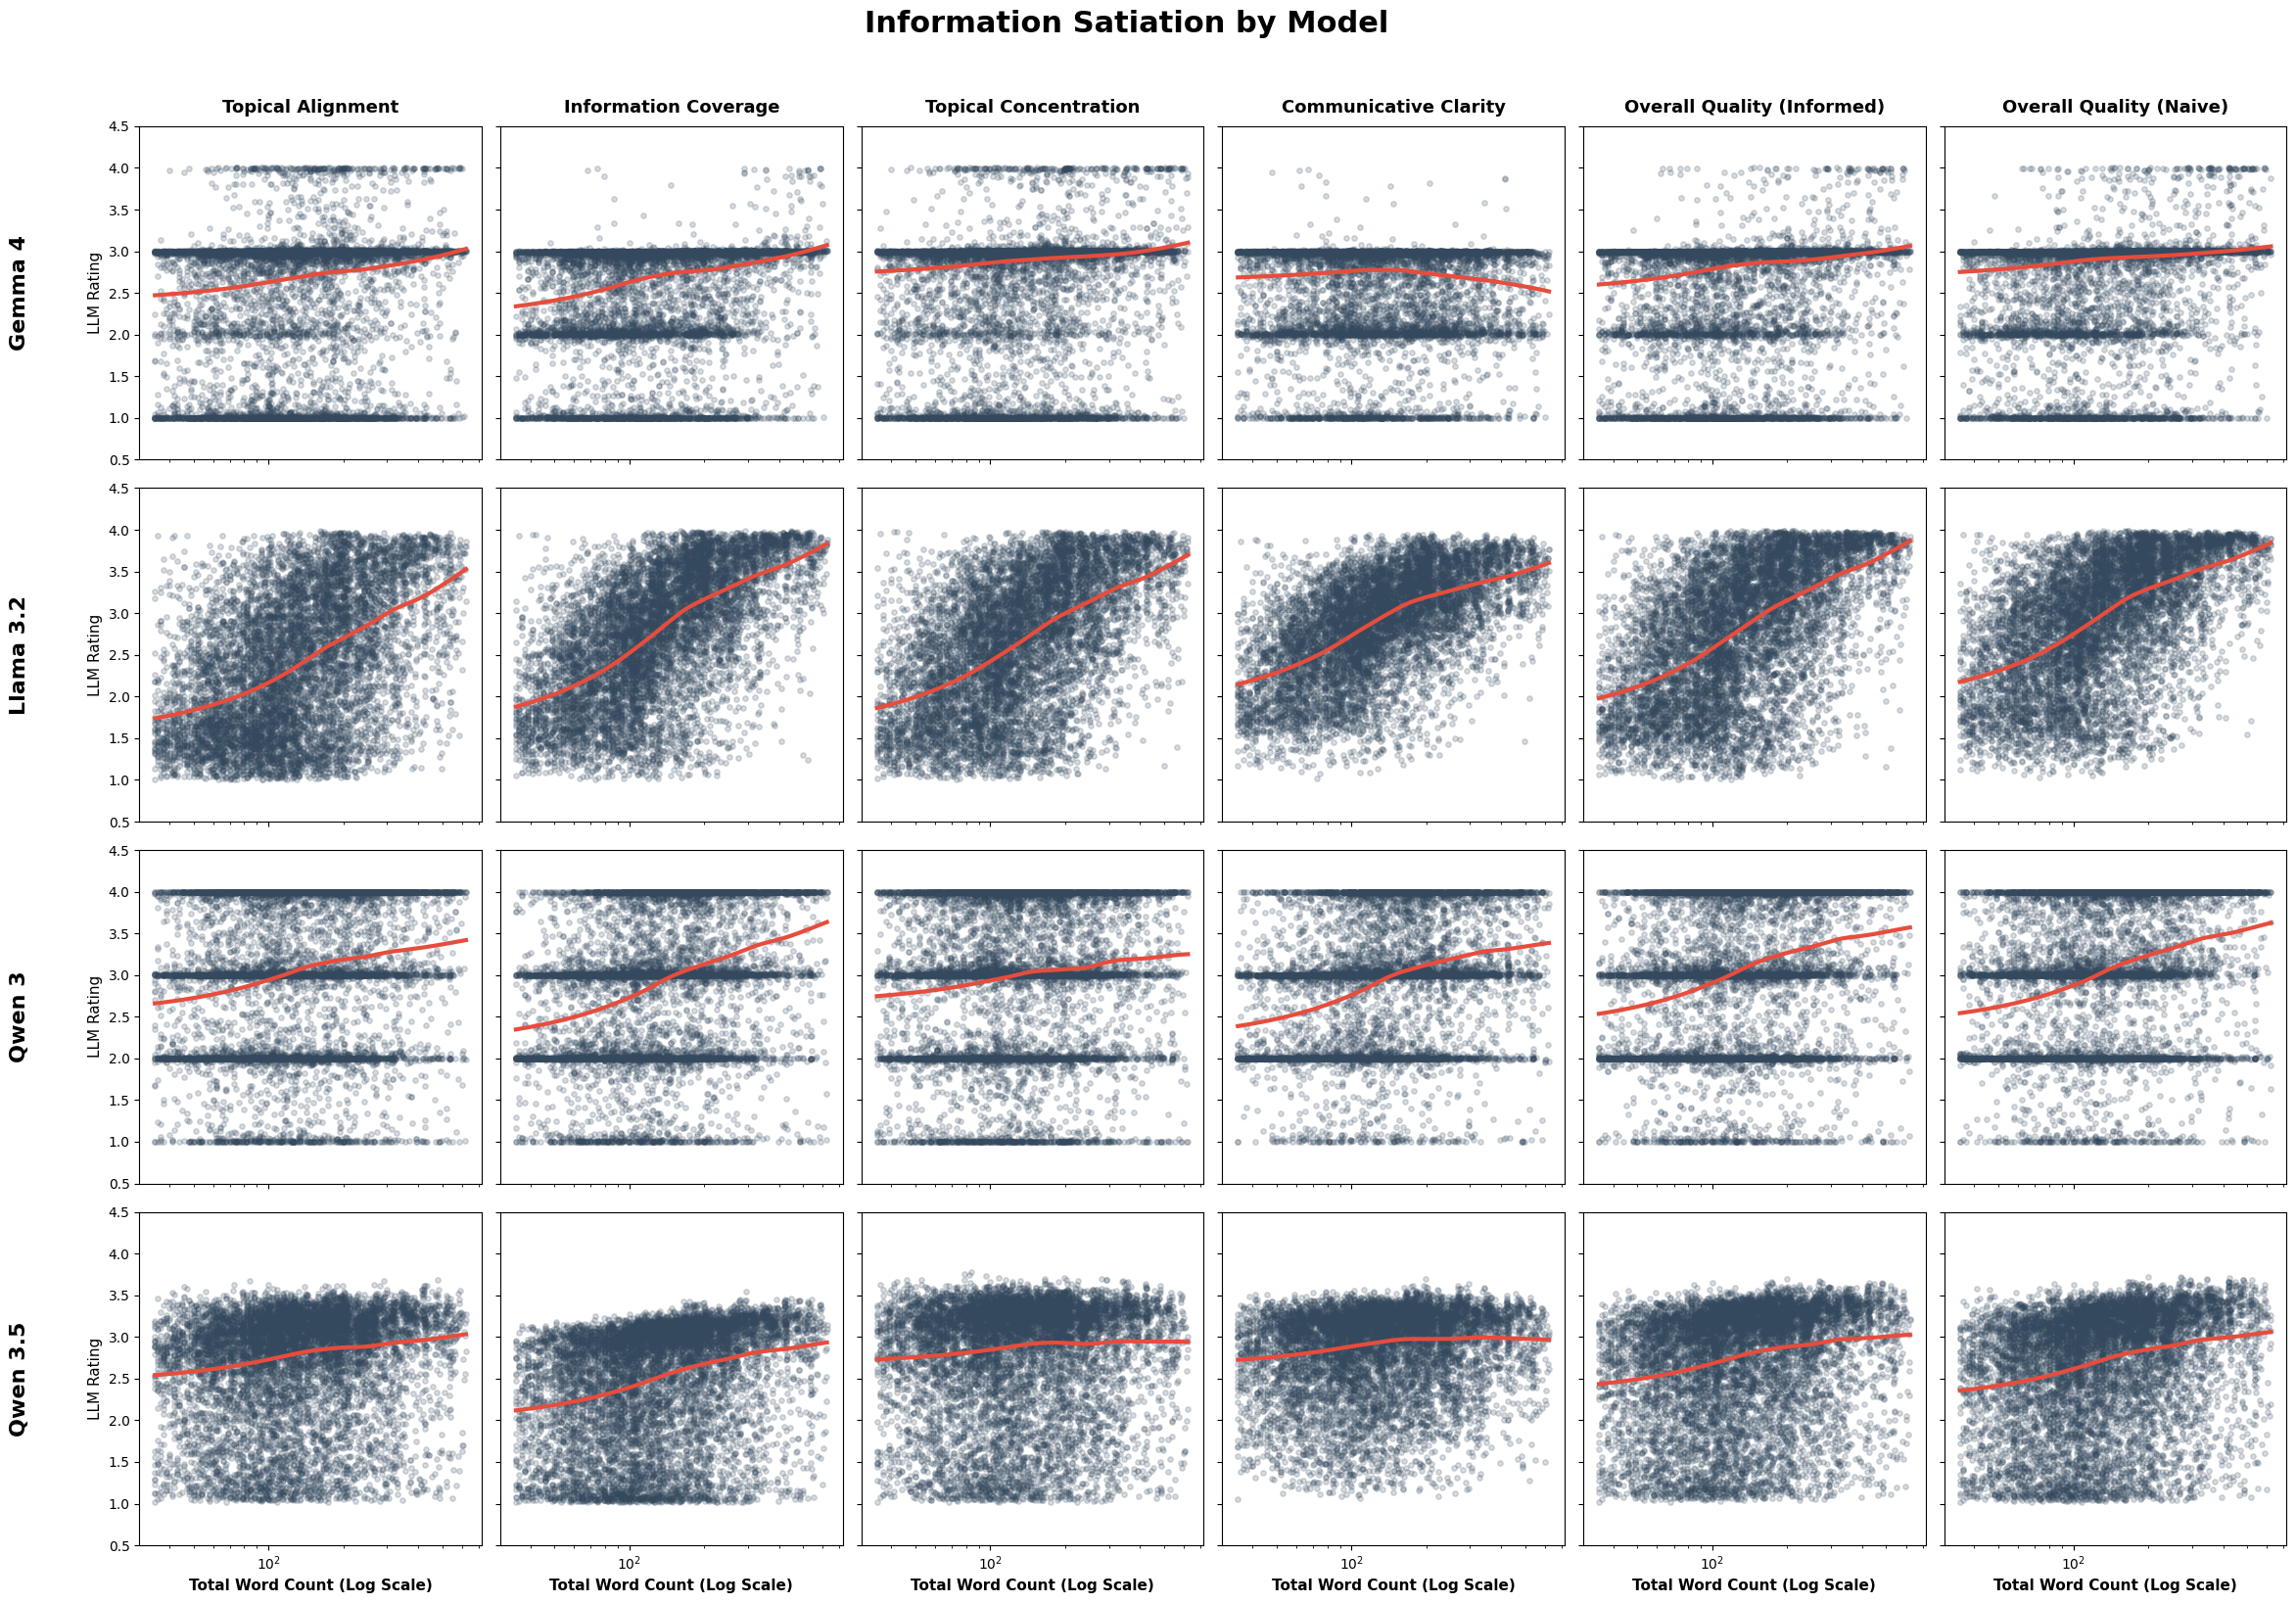

In [28]:
models = final_df['model_name_clean'].unique()
dimensions = final_df['dimension_name_clean'].unique()
plot_verbosity_grid(final_df,
                    models=models,
                    dimensions=dimensions,
                    model_col='model_name_clean',
                    dim_col='dimension_name_clean',
                    x_col='raw_input_word_count',
                    y_col='mean_rating',
                    lower_truncate_pct=0.02,
                    upper_truncate_pct=0.98,
                    y_min=0.5, y_max=4.5)

C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:332: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=res_df, x='Text Section', y='Absolute Cohen\'s d', hue='Model',


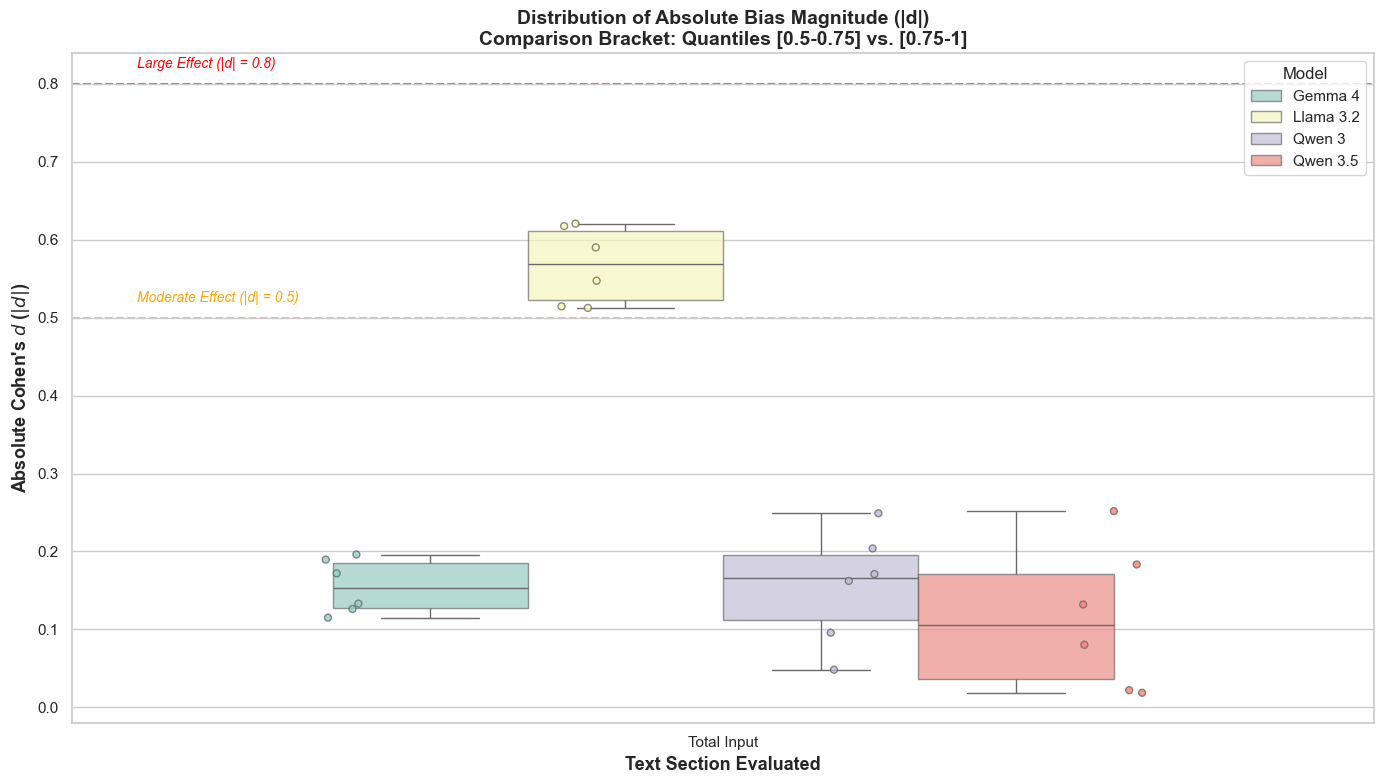

In [29]:
from src.general_analysis.visualisations import plot_absolute_bias_spread

sections = {
    'Total Input': 'raw_input_word_count'}

res_df_upperquart = plot_absolute_bias_spread(final_df, sections, p_lower=[
    0.5, 0.75], p_upper=[0.75, 1])

## Entropy

### Distribution

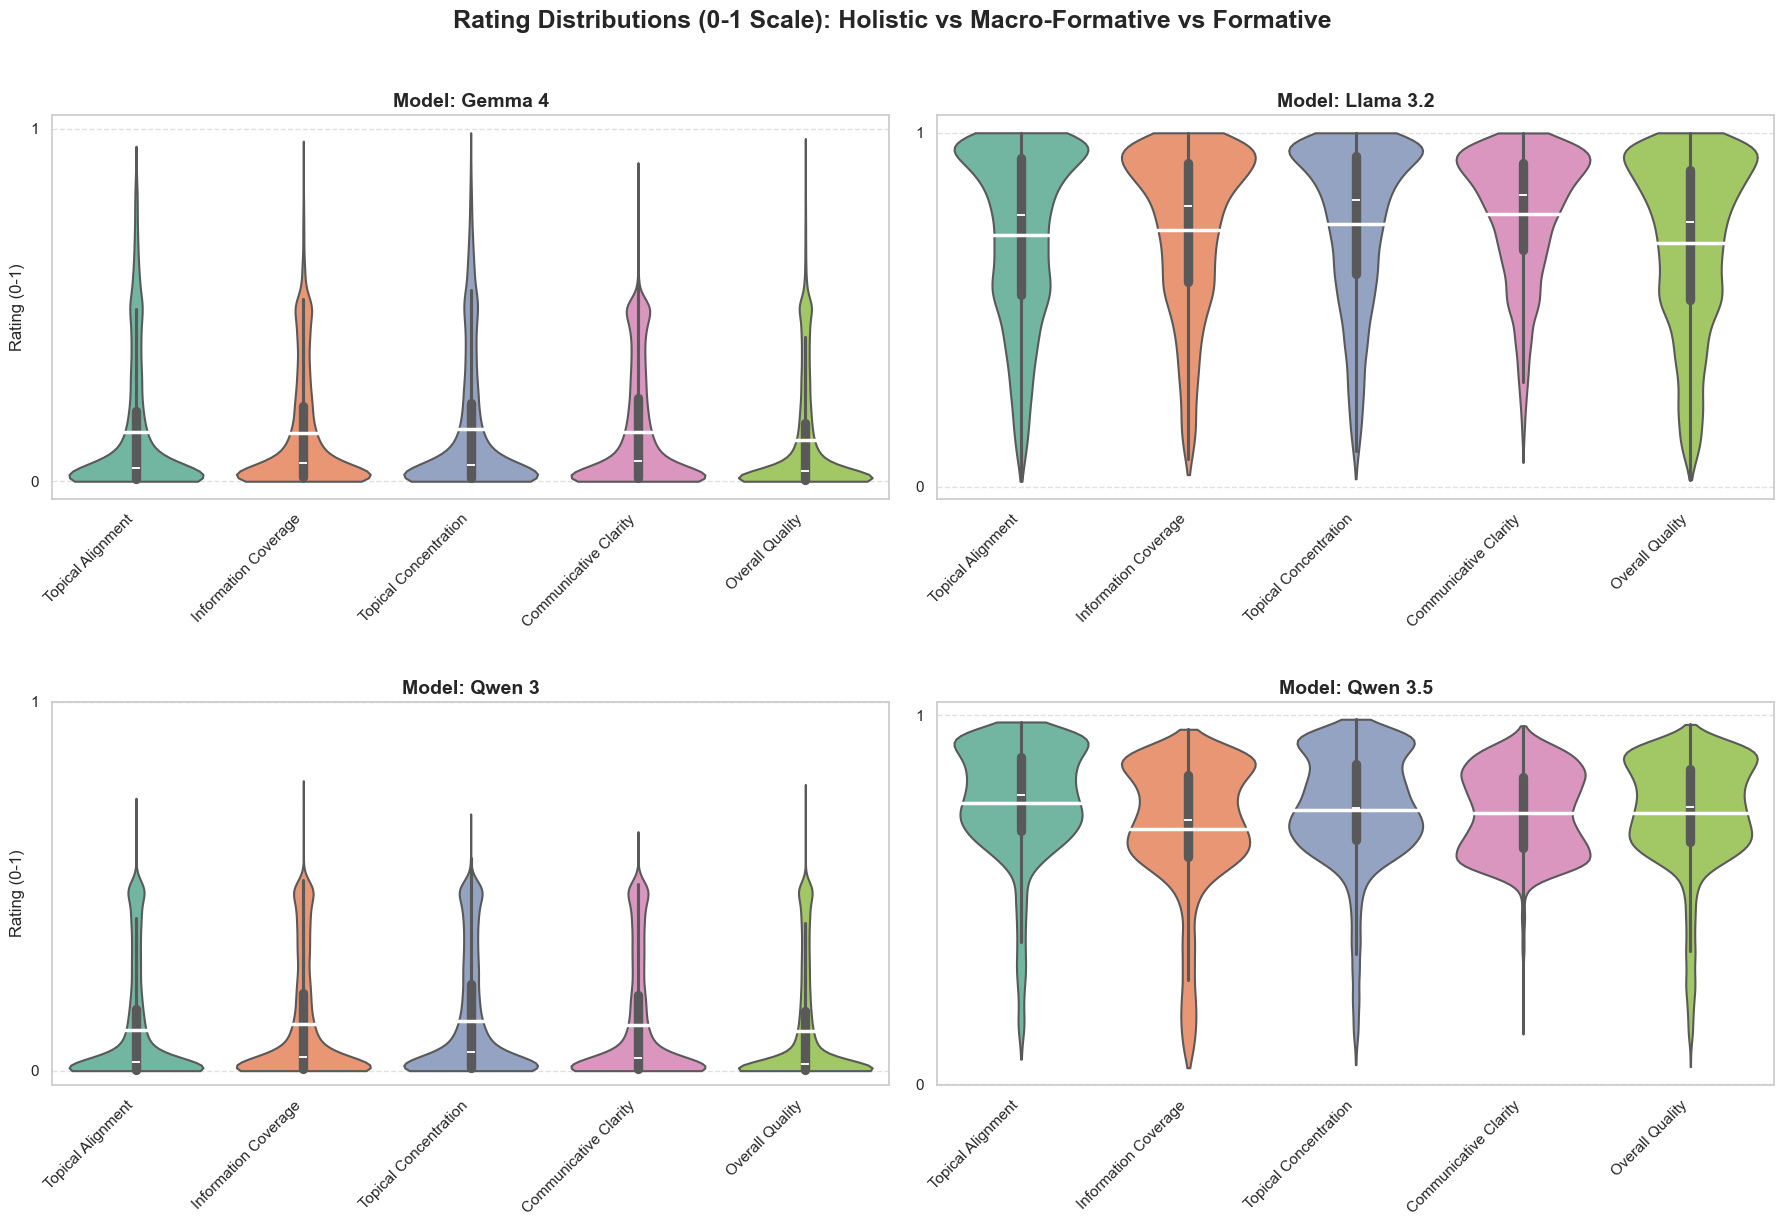

In [30]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (0, 1)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, score_col='normalized_entropy', rating_range=(0, 1), dim_map_clean=dim_map_clean)

In [31]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_disagreement = FeedbackQARegressionRunner(
    prompt_hash_map=prompt_hash_map,
    llm_prediction_col='normalized_entropy',
    covariates=['log_raw_input_word_count'],
    include_entropy=False,       # now adds entropy_* cols to iv_cols
    mode="disagreement"
)
runner_disagreement.run_regression(final_df)

✓ Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23780.49
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23758.90
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=9063 | AIC=23761.92
✓ Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23445.44
✓ Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23520.35
✓ Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=9063 | AIC=23473.20
✓ google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=9063 | AIC=23796.34
✓ google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=9063 | AIC=23814.88
✓ google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1

{'Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342f595e10>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342260ee90>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342db82650>,
 'Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x234225ba750>,
 'Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x2342e32b0d0>,
 'Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_mo

In [32]:
# runner_disagreement.summarize().to_csv(
#     'feedbackQA_disagreement_entropy_summary.csv')

In [33]:
interactive_regression_results_selector(runner_disagreement.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3-4B-Instruct-2507_For…

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                 
========================================================================================
Dep. Variable:     score_1_score_2_disagreement   R-squared:                       0.007
Model:                                      OLS   Adj. R-squared:                  0.007
Method:                           Least Squares   F-statistic:                     12.97
Date:                          Wed, 13 May 2026   Prob (F-statistic):           1.34e-12
Time:                                  02:04:28   Log-Likelihood:                -11884.
No. Observations:                          9063   AIC:                         2.378e+04
Df Residuals:                              9057   BIC:                         2.382e+04
Df Model:                                     5                                         
Covariance Type:                      nonrobust                                         
====================================================================================================================
                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
const                                                0.4341      0.067      6.440      0.000       0.302       0.566
normalized_entropy_qa_pair_communicative_clarity     0.0062      0.060      0.103      0.918      -0.111       0.124
normalized_entropy_qa_pair_information_coverage      0.0747      0.061      1.218      0.223      -0.046       0.195
normalized_entropy_qa_pair_topical_alignment         0.2354      0.065      3.633      0.000       0.108       0.362
normalized_entropy_qa_pair_topical_concentration     0.2211      0.062      3.554      0.000       0.099       0.343
log_raw_input_word_count                             0.0585      0.014      4.295      0.000       0.032       0.085
==============================================================================
Omnibus:                      951.393   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1287.201
Skew:                           0.923   Prob(JB):                    3.07e-280
Kurtosis:                       2.956   Cond. No.                         39.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Recontextualizing Human Disagreement: Beyond Judge Idiosyncrasy

"The finding that foundational LLM entropy systematically predicts human disagreement offers a critical counter-perspective to recent calibrative frameworks in NLP. For instance, the Microsoft LLM-RUBRIC framework approaches human variance by explicitly training models to capture the 'idiosyncrasies of individual judges,' operating under the assumption that purely objective textual scores do not exist (Microsoft, 2023).

While we align with their foundational premise that 'disagreement is signal rather than noise' (Aroyo and Welty, 2015), our entropy regression challenges the locus of that signal. Because Qwen 3.5 evaluates the text in a vacuum—entirely blind to the subjective profiles of the human raters—its predictive power (R2≈0.043) cannot be attributed to modeling judge heterogeneity. Instead, it mathematically demonstrates that human disagreement is significantly driven by the objective, structural ambiguity of the text itself. When a text is poorly specified, humans diverge; simultaneously, the LLM’s probability distribution widens.

Consequently, this research suggests that complex, post-hoc human calibration networks may not be strictly necessary to capture evaluation uncertainty. By leveraging the raw log-probabilities of a well-calibrated open-weights model, researchers can measure semantic indeterminacy directly at the source, preserving the formative evaluation of the text without conflating it with the subjective quirks of the human annotators."

Note on Effect Size and Explanatory Power


"While an R2 of 0.043 indicates that the model explains a relatively small fraction of the total variance in human disagreement, this is entirely expected within the context of behavioral psychometrics. Human disagreement is a heavily compounded variable, driven by countless unobservable factors outside the text itself, including rater fatigue, demographic background, and random error. The objective of this regression is not to build a deterministic predictive model of human behavior, but rather to test for the presence of a structural signal. Explaining over 4% of this highly noisy, subjective variance using only two variables—text length and the foundational math of an LLM—provides robust empirical proof that a latent semantic signal exists, confirming the theoretical validity of open-weights entropy as a proxy for structural ambiguity."



The Impact of Output Distribution on Entropy-Based Signal Extraction

"Given the large sample size (N=9,063), evaluating the utility of the entropy metric requires isolating the mechanical differences in model output distributions. As observed, models such as Gemma 4 and Qwen 3 exhibit mode collapse, restricting their probability mass to single integers. Consequently, their internal entropy is constrained and fails to correlate meaningfully with human disagreement (R2≈0.005 and 0.008, respectively), representing baseline statistical noise.

Qwen 3.5 avoids this mode collapse, maintaining a continuous log-probability distribution. When regressed against human disagreement, its entropy yields an R2 of 0.043. While the absolute variance explained is small—as is standard when predicting heavily compounded human behavioral metrics—it demonstrates that a well-calibrated, continuous foundational model captures a statistically valid structural signal of semantic ambiguity. Models constrained by integer-sticking structurally destroy this signal."

### Correlation with disagreement


#### Table

In [34]:
analyzer = ReliabilityAnalyzer(
    final_df, group_cols=['model_name', 'prompt_name', 'dimension_name_clean'])
df_corr = analyzer.analyze_calibration('human_disagreement')
df_corr
# analyzer.analyze_calibration('human_disagreement').to_csv('feedbackQA_disagreement_entropy_corr.csv')

,model_name,prompt_name,dimension_name_clean,calibration_corr
0,Qwen/Qwen3-4B-Instruct-2507,Formative,Communicative Clarity,0.035273
1,Qwen/Qwen3-4B-Instruct-2507,Formative,Information Coverage,0.066067
2,Qwen/Qwen3-4B-Instruct-2507,Formative,Topical Alignment,0.094710
3,Qwen/Qwen3-4B-Instruct-2507,Formative,Topical Concentration,0.091859
4,Qwen/Qwen3-4B-Instruct-2507,Holistic Informed,Overall Quality (Informed),0.115023
5,Qwen/Qwen3-4B-Instruct-2507,Holistic Naive,Overall Quality (Naive),0.121466
6,Qwen/Qwen3.5-4B,Formative,Communicative Clarity,0.056448
7,Qwen/Qwen3.5-4B,Formative,Information Coverage,0.196395
8,Qwen/Qwen3.5-4B,Formative,Topical Alignment,0.139433
9,Qwen/Qwen3.5-4B,Formative,Topical Concentration,0.114359


#### Bar Chart

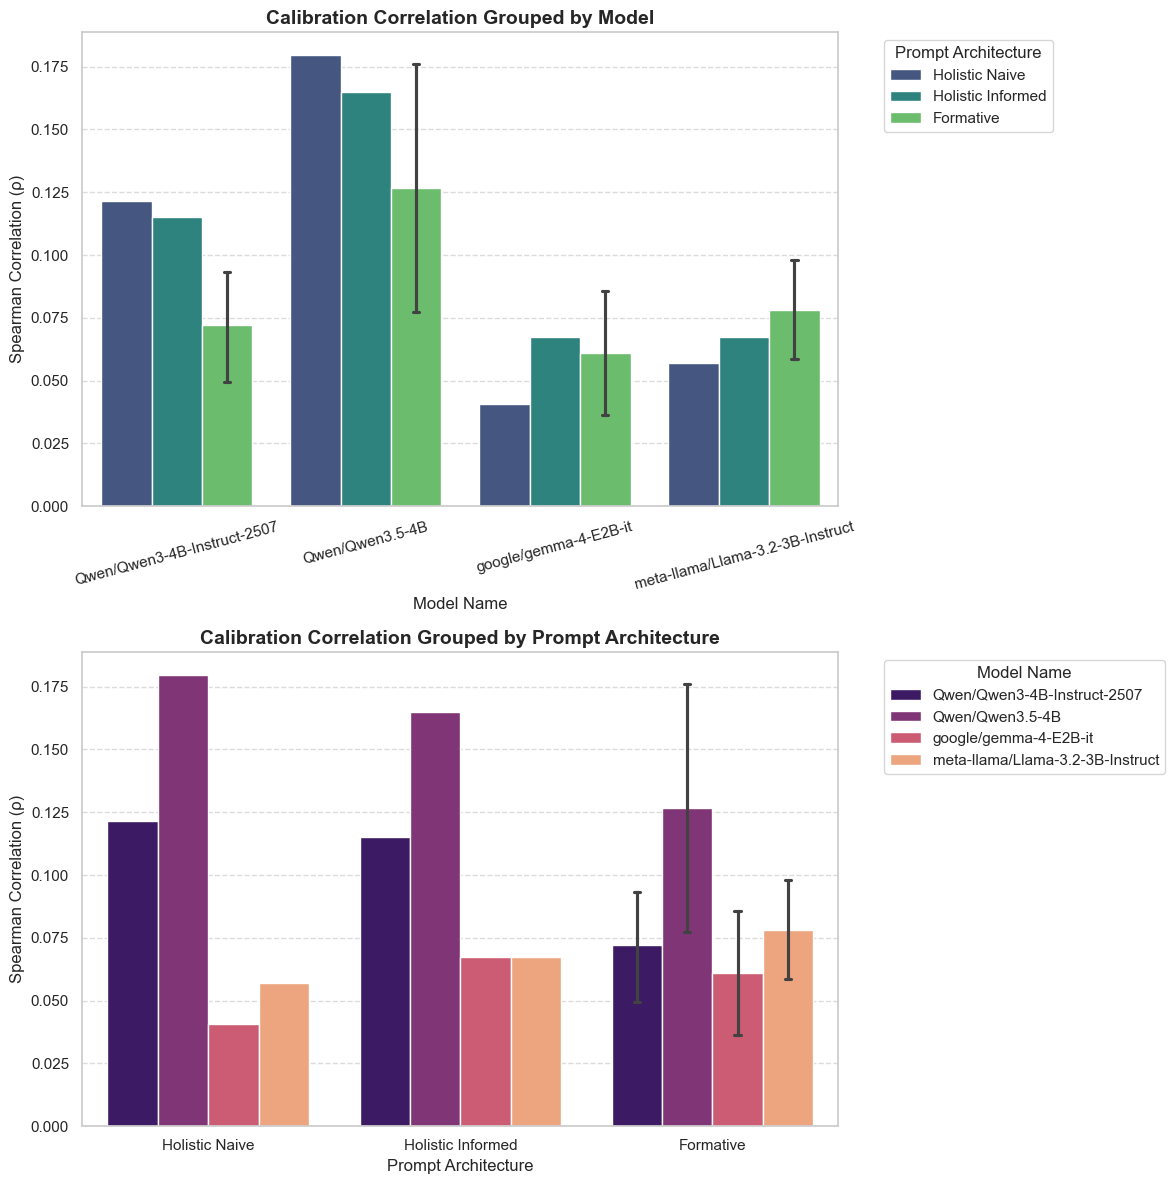

In [35]:
from src.feedbackqa.visualisations import plot_calibration_correlation_comparisons


# Render it interactively in Jupyter
plot_calibration_correlation_comparisons(df_corr)

# Save it directly for your thesis
# plot_calibration_correlation_comparisons(df_corr, save_path='figures/correlation_comparisons.png')

#### Violin plot

In [36]:
# from src.feedbackqa.visualisations import plot_entropy_disagreement_violin_grid
# plot_entropy_disagreement_violin_grid(final_df)

##  Inter-rater reliability

In [37]:
analyzer = ReliabilityAnalyzer(final_df, group_cols=[
                               'model_name', 'prompt_id', 'dimension_name'], llm_rating_col='mean_rating')
analyzer.compute_reliability_gap(metric='spearman')

,model_name,prompt_id,dimension_name,metric_type,spearman_gap,spearman_hh,spearman_llm_avg
1,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_information_coverage,Spearman,-0.031385,0.540923,0.572308
7,Qwen/Qwen3.5-4B,83fb9645af53,qa_pair_information_coverage,Spearman,-0.030364,0.540923,0.571287
4,Qwen/Qwen3-4B-Instruct-2507,f1ea5fbc4957,qa_pair_overall_answer_quality,Spearman,-0.026085,0.540923,0.567008
2,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_topical_alignment,Spearman,-0.022182,0.540923,0.563105
5,Qwen/Qwen3-4B-Instruct-2507,f926cb88b5c8,qa_pair_overall_answer_quality,Spearman,-0.019690,0.540923,0.560612
11,Qwen/Qwen3.5-4B,f926cb88b5c8,qa_pair_overall_answer_quality,Spearman,-0.015557,0.540923,0.556480
10,Qwen/Qwen3.5-4B,f1ea5fbc4957,qa_pair_overall_answer_quality,Spearman,-0.012948,0.540923,0.553871
3,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_topical_concentration,Spearman,0.000002,0.540923,0.540921
8,Qwen/Qwen3.5-4B,83fb9645af53,qa_pair_topical_alignment,Spearman,0.002026,0.540923,0.538897
0,Qwen/Qwen3-4B-Instruct-2507,83fb9645af53,qa_pair_communicative_clarity,Spearman,0.005356,0.540923,0.535567


# Regression

## Mean

In [ ]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_mean = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    covariates=['log_raw_input_word_count'],
    include_entropy=False,       # now adds entropy_* cols to iv_cols
    mode="rating",
    model_col='model_name_clean'
)
runner_mean.run_regression(final_df)

diagnostics_mean = collect_all_diagnostics(runner_mean)
ov_mean = overview(diagnostics_mean)

✓ Gemma 4_Formative | n=18126 | AIC=54693.12
✓ Gemma 4_Holistic Informed | n=18126 | AIC=55241.29
✓ Gemma 4_Holistic Naive | n=18126 | AIC=55519.76
✓ Llama 3.2_Formative | n=18126 | AIC=55812.71
✓ Llama 3.2_Holistic Informed | n=18126 | AIC=56306.91
✓ Llama 3.2_Holistic Naive | n=18126 | AIC=56321.66
✓ Qwen 3_Formative | n=18126 | AIC=52091.79
✓ Qwen 3_Holistic Informed | n=18126 | AIC=52808.60
✓ Qwen 3_Holistic Naive | n=18126 | AIC=52998.24
✓ Qwen 3.5_Formative | n=18126 | AIC=52117.71
✓ Qwen 3.5_Holistic Informed | n=18126 | AIC=52658.78
✓ Qwen 3.5_Holistic Naive | n=18126 | AIC=52613.78


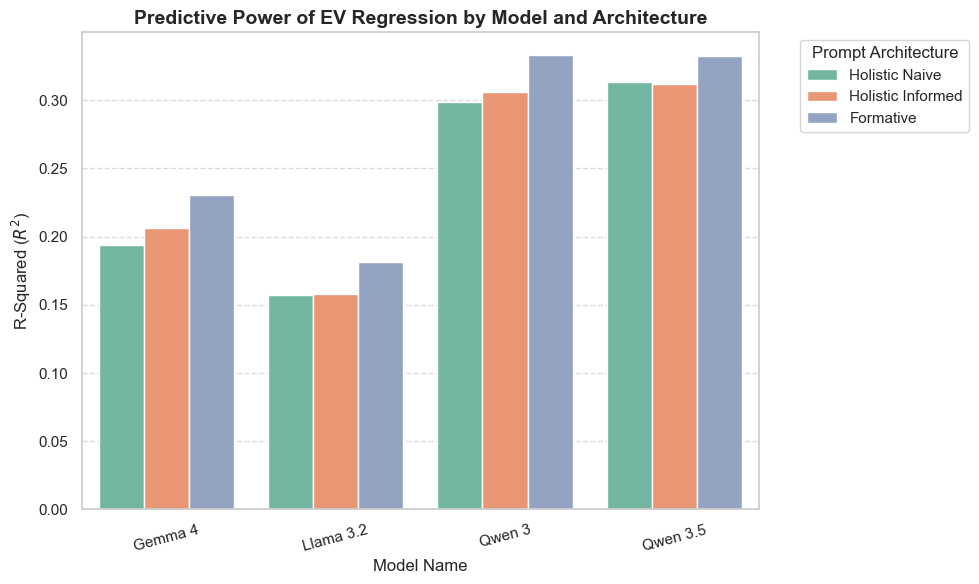

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [39]:
from src.feedbackqa.visualisations import plot_ev_regression_r2

df_results = ov_mean['metrics']
plot_ev_regression_r2(df_results)

In [40]:
interactive_dataframe_selector(ov_mean)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('metrics', 'coefficients', 'vif'…

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,Gemma 4_Formative,18126.0,0.230169,0.229956,NaN,54693.121461,54739.952077,-27340.560731,63.793078,6.213968
1,Gemma 4_Holistic Informed,18126.0,0.206269,0.206181,NaN,55241.290100,55264.705408,-27617.645050,42.147221,1.225243
2,Gemma 4_Holistic Naive,18126.0,0.193981,0.193892,NaN,55519.757047,55543.172355,-27756.878523,42.836553,1.237154
3,Llama 3.2_Formative,18126.0,0.181119,0.180893,NaN,55812.709823,55859.540439,-27900.354912,65.984041,10.119759
4,Llama 3.2_Holistic Informed,18126.0,0.158207,0.158114,NaN,56306.907974,56330.323282,-28150.453987,41.760155,1.872585
5,Llama 3.2_Holistic Naive,18126.0,0.157522,0.157429,NaN,56321.658750,56345.074057,-28157.829375,41.992996,1.863292
6,Qwen 3_Formative,18126.0,0.333088,0.332904,NaN,52091.794980,52138.625596,-26039.897490,63.472128,7.623504
7,Qwen 3_Holistic Informed,18126.0,0.305957,0.305880,NaN,52808.598235,52832.013543,-26401.299117,43.063066,1.338482
8,Qwen 3_Holistic Naive,18126.0,0.298657,0.298580,NaN,52998.240000,53021.655308,-26496.120000,42.970828,1.353520
9,Qwen 3.5_Formative,18126.0,0.332134,0.331950,NaN,52117.708115,52164.538731,-26052.854057,76.257976,7.935938


In [41]:
interactive_regression_results_selector(runner_mean.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.230
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     1028.
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        02:04:32   Log-Likelihood:                -27341.
No. Observations:               18126   AIC:                         5.469e+04
Df Residuals:                   18120   BIC:                         5.474e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
=============================================================================================================
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
const                                        -0.8163      0.076    -10.803      0.000      -0.964      -0.668
mean_rating_qa_pair_communicative_clarity     0.1029      0.026      3.962      0.000       0.052       0.154
mean_rating_qa_pair_information_coverage      0.2985      0.031      9.532      0.000       0.237       0.360
mean_rating_qa_pair_topical_alignment         0.3706      0.030     12.375      0.000       0.312       0.429
mean_rating_qa_pair_topical_concentration    -0.0330      0.032     -1.034      0.301      -0.096       0.030
log_raw_input_word_count                      0.2953      0.015     19.601      0.000       0.266       0.325
==============================================================================
Omnibus:                     2498.028   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              647.523
Skew:                          -0.114   Prob(JB):                    2.47e-141
Kurtosis:                       2.102   Cond. No.                         63.8
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [42]:
runner_mean.compute_vifs()

,group,predictor,vif,flagged
0,Gemma 4_Formative,mean_rating_qa_pair_topical_concentration,6.751,True
1,Gemma 4_Formative,mean_rating_qa_pair_topical_alignment,6.367,True
2,Gemma 4_Formative,mean_rating_qa_pair_information_coverage,5.065,True
3,Gemma 4_Formative,mean_rating_qa_pair_communicative_clarity,2.950,False
4,Gemma 4_Formative,log_raw_input_word_count,1.185,False
5,Gemma 4_Holistic Informed,mean_rating,1.042,False
6,Gemma 4_Holistic Informed,log_raw_input_word_count,1.042,False
7,Gemma 4_Holistic Naive,mean_rating,1.046,False
8,Gemma 4_Holistic Naive,log_raw_input_word_count,1.046,False
9,Llama 3.2_Formative,mean_rating_qa_pair_information_coverage,16.931,True


## Mode

In [43]:
# Predicting ratings (original behaviour, entropy now actually included)
runner_mode = FeedbackQARegressionRunner(
    prompt_hash_map=prompt_hash_map,
    llm_prediction_col='mode_rating',
    covariates=['raw_input_word_count'],
    include_entropy=True,       # now adds entropy_* cols to iv_cols
    mode="rating"
)
runner_mode.run_regression(final_df)

diagnostics_mode = collect_all_diagnostics(runner_mode)
ov_mode = overview(diagnostics_mode)

✓ Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=18126 | AIC=52272.95
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=18126 | AIC=53160.79
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=18126 | AIC=53388.70
✓ Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=18126 | AIC=53099.87
✓ Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=18126 | AIC=54252.83
✓ Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=18126 | AIC=54223.60
✓ google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=18126 | AIC=54885.27
✓ google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=18126 | AIC=55510.77
✓ google/gemma-4-E2B-it_Holistic naive v2, scale 4, system p

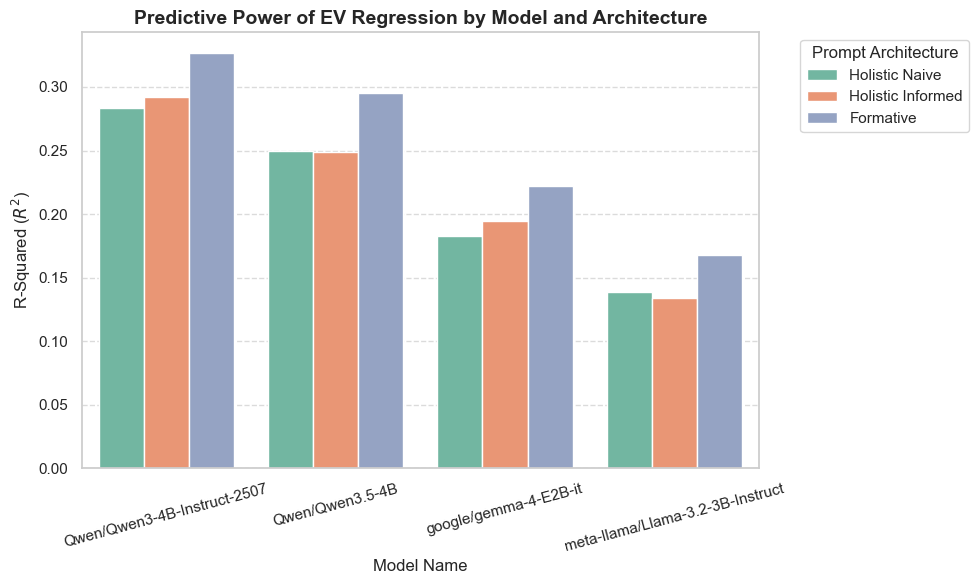

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [44]:
from src.feedbackqa.visualisations import plot_ev_regression_r2

# Load your results
df_results = ov_mode['metrics']

# Render it interactively
plot_ev_regression_r2(df_results)

In [45]:
interactive_dataframe_selector(ov_mode)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('metrics', 'coefficients', 'vif'…

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scal...",18126.0,0.326687,0.326352,NaN,52272.945817,52350.996843,-26126.472908,1765.284856,6.015579
1,Qwen/Qwen3-4B-Instruct-2507_Holistic informed ...,18126.0,0.292417,0.292300,NaN,53160.792677,53192.013088,-26576.396339,1506.465122,1.272905
2,"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2,...",18126.0,0.283464,0.283346,NaN,53388.704953,53419.925364,-26690.352477,1452.427024,1.265662
3,"Qwen/Qwen3.5-4B_Formative v3, scale 4, system ...",18126.0,0.295258,0.294908,NaN,53099.866264,53177.917290,-26539.933132,4094.803243,5.257127
4,"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4,...",18126.0,0.248477,0.248353,NaN,54252.833356,54284.053767,-27122.416678,1942.911877,1.403594
5,"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, sy...",18126.0,0.249688,0.249564,NaN,54223.601889,54254.822300,-27107.800944,1733.661207,1.433476
6,"google/gemma-4-E2B-it_Formative v3, scale 4, s...",18126.0,0.222308,0.221921,NaN,54885.270427,54963.321453,-27432.635213,1838.275106,5.203668
7,"google/gemma-4-E2B-it_Holistic informed v2, sc...",18126.0,0.194469,0.194336,NaN,55510.771769,55541.992179,-27751.385884,1372.694898,1.208135
8,"google/gemma-4-E2B-it_Holistic naive v2, scale...",18126.0,0.182677,0.182542,NaN,55774.195827,55805.416237,-27883.097913,1443.955289,1.256525
9,"meta-llama/Llama-3.2-3B-Instruct_Formative v3,...",18126.0,0.167924,0.167511,NaN,56110.449809,56188.500836,-28045.224905,3400.222711,6.665046


In [46]:
interactive_regression_results_selector(runner_mode.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3-4B-Instruct-2507_For…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     980.6
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        02:04:36   Log-Likelihood:                -26126.
No. Observations:               18126   AIC:                         5.227e+04
Df Residuals:                   18116   BIC:                         5.235e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
====================================================================================================================
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
const                                                0.0037      0.032      0.118      0.906      -0.058       0.066
mode_rating_qa_pair_communicative_clarity            0.1354      0.022      6.247      0.000       0.093       0.178
mode_rating_qa_pair_information_coverage             0.2731      0.026     10.684      0.000       0.223       0.323
mode_rating_qa_pair_topical_alignment                0.2824      0.025     11.189      0.000       0.233       0.332
mode_rating_qa_pair_topical_concentration            0.1155      0.023      4.945      0.000       0.070       0.161
normalized_entropy_qa_pair_communicative_clarity     0.1707      0.056      3.027      0.002       0.060       0.281
normalized_entropy_qa_pair_information_coverage     -0.0989      0.060     -1.641      0.101      -0.217       0.019
normalized_entropy_qa_pair_topical_alignment         0.1263      0.063      2.000      0.045       0.003       0.250
normalized_entropy_qa_pair_topical_concentration    -0.1384      0.059     -2.345      0.019      -0.254      -0.023
raw_input_word_count                                 0.0006    7.1e-05      9.025      0.000       0.001       0.001
==============================================================================
Omnibus:                      296.302   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              172.765
Skew:                          -0.051   Prob(JB):                     3.05e-38
Kurtosis:                       2.533   Cond. No.                     1.77e+03
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
[2] The condition number is large, 1.77e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Difference mean mode

In [47]:
diff_mean_mode = ov_mean['metrics'].iloc[:, 2:] - \
    ov_mode['metrics'].iloc[:, 2:]
diff_mean_mode['label'] = ov_mean['metrics'].iloc[:, 0]
diff_mean_mode

,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number,label
0,-0.096518,-0.096396,NaN,2420.175645,2388.955234,-1214.087822,-1701.491778,0.198389,Gemma 4_Formative
1,-0.086148,-0.086119,NaN,2080.497423,2072.692320,-1041.248712,-1464.317901,-0.047661,Gemma 4_Holistic Informed
2,-0.089483,-0.089454,NaN,2131.052094,2123.246991,-1066.526047,-1409.590471,-0.028508,Gemma 4_Holistic Naive
3,-0.114139,-0.114015,NaN,2712.843560,2681.623149,-1360.421780,-4028.819202,4.862632,Llama 3.2_Formative
4,-0.090270,-0.090238,NaN,2054.074617,2046.269515,-1028.037309,-1901.151723,0.468991,Llama 3.2_Holistic Informed
5,-0.092166,-0.092135,NaN,2098.056861,2090.251758,-1050.028430,-1691.668211,0.429816,Llama 3.2_Holistic Naive
6,0.110780,0.110983,NaN,-2793.475447,-2824.695857,1392.737723,-1774.802979,2.419836,Qwen 3_Formative
7,0.111487,0.111544,NaN,-2702.173534,-2709.978636,1350.086767,-1329.631832,0.130347,Qwen 3_Holistic Informed
8,0.115980,0.116038,NaN,-2775.955827,-2783.760929,1386.977913,-1400.984461,0.096994,Qwen 3_Holistic Naive
9,0.164210,0.164439,NaN,-3992.741694,-4023.962105,1992.370847,-3323.964735,1.270892,Qwen 3.5_Formative


In [48]:
df_results

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scal...",18126.0,0.326687,0.326352,NaN,52272.945817,52350.996843,-26126.472908,1765.284856,6.015579
1,Qwen/Qwen3-4B-Instruct-2507_Holistic informed ...,18126.0,0.292417,0.292300,NaN,53160.792677,53192.013088,-26576.396339,1506.465122,1.272905
2,"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2,...",18126.0,0.283464,0.283346,NaN,53388.704953,53419.925364,-26690.352477,1452.427024,1.265662
3,"Qwen/Qwen3.5-4B_Formative v3, scale 4, system ...",18126.0,0.295258,0.294908,NaN,53099.866264,53177.917290,-26539.933132,4094.803243,5.257127
4,"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4,...",18126.0,0.248477,0.248353,NaN,54252.833356,54284.053767,-27122.416678,1942.911877,1.403594
5,"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, sy...",18126.0,0.249688,0.249564,NaN,54223.601889,54254.822300,-27107.800944,1733.661207,1.433476
6,"google/gemma-4-E2B-it_Formative v3, scale 4, s...",18126.0,0.222308,0.221921,NaN,54885.270427,54963.321453,-27432.635213,1838.275106,5.203668
7,"google/gemma-4-E2B-it_Holistic informed v2, sc...",18126.0,0.194469,0.194336,NaN,55510.771769,55541.992179,-27751.385884,1372.694898,1.208135
8,"google/gemma-4-E2B-it_Holistic naive v2, scale...",18126.0,0.182677,0.182542,NaN,55774.195827,55805.416237,-27883.097913,1443.955289,1.256525
9,"meta-llama/Llama-3.2-3B-Instruct_Formative v3,...",18126.0,0.167924,0.167511,NaN,56110.449809,56188.500836,-28045.224905,3400.222711,6.665046


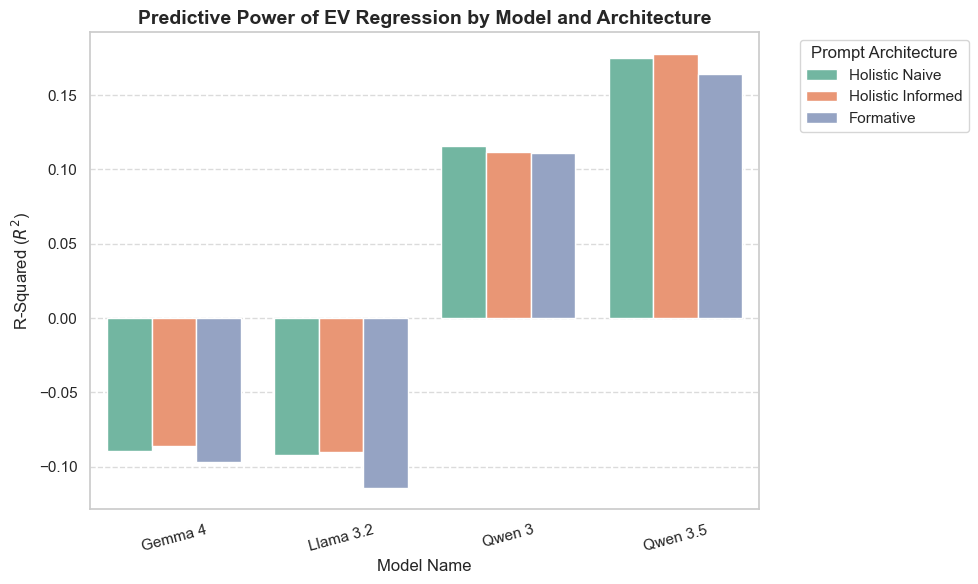

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [49]:
# Load your results
# df_results = ov_mode['metrics']

# Render it interactively
plot_ev_regression_r2(diff_mean_mode)

## Models including entropy

I settle upon the log raw input word count as opposed to the length bucket, since the results were nearly the same (delta AIC <4), and the normalized condition number is higher for the length bucket. This indicates that a log transformed length is sufficient to account for the model dynamics of text length.

In [ ]:
runner_mean_entr = FeedbackQARegressionRunner(
    experimental_groups=['model_name_clean', 'prompt_id'],
    prompt_hash_map=prompt_map_clean,
    llm_prediction_col='mean_rating',
    include_entropy=True,
    mode="rating",
    covariates=['log_raw_input_word_count'],
    categorical_covariates=[],
    model_col='model_name_clean'
)
runner_mean_entr.run_regression(final_df)

# interactive_regression_results_selector(runner_mean_entr.results)

diagnostics_mean_entr = collect_all_diagnostics(runner_mean_entr)
ov_mean_entr = overview(diagnostics_mean_entr)
interactive_dataframe_selector(ov_mean_entr)

✓ Gemma 4_Formative | n=18126 | AIC=54476.14
✓ Gemma 4_Holistic Informed | n=18126 | AIC=55039.13
✓ Gemma 4_Holistic Naive | n=18126 | AIC=55322.49
✓ Llama 3.2_Formative | n=18126 | AIC=55676.41
✓ Llama 3.2_Holistic Informed | n=18126 | AIC=56306.72
✓ Llama 3.2_Holistic Naive | n=18126 | AIC=56304.16
✓ Qwen 3_Formative | n=18126 | AIC=52078.23
✓ Qwen 3_Holistic Informed | n=18126 | AIC=52809.30
✓ Qwen 3_Holistic Naive | n=18126 | AIC=52997.94
✓ Qwen 3.5_Formative | n=18126 | AIC=51961.50
✓ Qwen 3.5_Holistic Informed | n=18126 | AIC=52540.06
✓ Qwen 3.5_Holistic Naive | n=18126 | AIC=52524.31


Dropdown(description='Select option:', layout=Layout(width='400px'), options=('metrics', 'coefficients', 'vif'…

,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,raw_condition_number,standardized_condition_number
0,Gemma 4_Formative,18126.0,0.239665,0.239287,NaN,54476.135781,54554.186808,-27228.067891,64.723963,6.597476
1,Gemma 4_Holistic Informed,18126.0,0.215159,0.215029,NaN,55039.130876,55070.351286,-27515.565438,42.924726,1.262056
2,Gemma 4_Holistic Naive,18126.0,0.202793,0.202662,NaN,55322.485413,55353.705824,-27657.242707,44.143395,1.305836
3,Llama 3.2_Formative,18126.0,0.187612,0.187209,NaN,55676.409757,55754.460784,-27828.204879,123.068216,11.368459
4,Llama 3.2_Holistic Informed,18126.0,0.158309,0.158169,NaN,56306.717296,56337.937707,-28149.358648,53.512601,2.000210
5,Llama 3.2_Holistic Naive,18126.0,0.158427,0.158288,NaN,56304.160851,56335.381261,-28148.080425,58.860995,2.073036
6,Qwen 3_Formative,18126.0,0.333881,0.333550,NaN,52078.226655,52156.277682,-26029.113328,64.643481,7.763603
7,Qwen 3_Holistic Informed,18126.0,0.306006,0.305892,NaN,52809.296156,52840.516566,-26400.648078,44.344393,1.368667
8,Qwen 3_Holistic Naive,18126.0,0.298746,0.298630,NaN,52997.937859,53029.158270,-26494.968930,43.760779,1.358061
9,Qwen 3.5_Formative,18126.0,0.338157,0.337828,NaN,51961.501450,52039.552476,-25970.750725,145.751360,8.604679


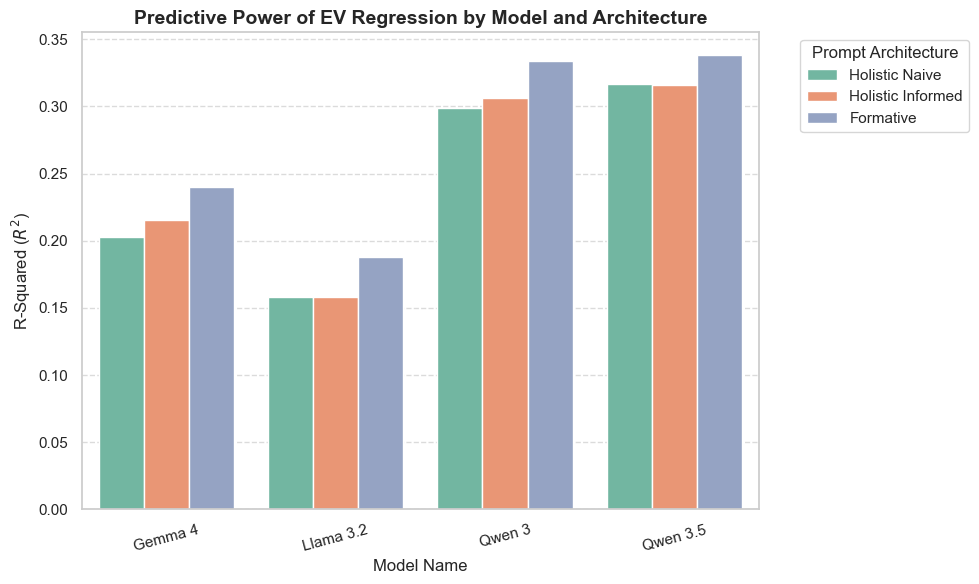

<Axes: title={'center': 'Predictive Power of EV Regression by Model and Architecture'}, xlabel='Model Name', ylabel='R-Squared ($R^2$)'>

In [51]:
# Load your results
df_results = ov_mean_entr['metrics']

# Render it interactively
plot_ev_regression_r2(df_results)

In [52]:
5212 - 5196

16

In [53]:
interactive_regression_results_selector(runner_mean_entr.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4_Formative', 'Gemma 4_Ho…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       raw_human_rating   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     576.5
Date:                Wed, 13 May 2026   Prob (F-statistic):               0.00
Time:                        02:04:40   Log-Likelihood:                -27228.
No. Observations:               18126   AIC:                         5.448e+04
Df Residuals:                   18116   BIC:                         5.455e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
====================================================================================================================
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
const                                               -0.6779      0.075     -9.014      0.000      -0.825      -0.530
mean_rating_qa_pair_communicative_clarity            0.1130      0.026      4.340      0.000       0.062       0.164
mean_rating_qa_pair_information_coverage             0.2980      0.032      9.434      0.000       0.236       0.360
mean_rating_qa_pair_topical_alignment                0.2961      0.031      9.559      0.000       0.235       0.357
mean_rating_qa_pair_topical_concentration            0.0179      0.033      0.548      0.584      -0.046       0.082
normalized_entropy_qa_pair_communicative_clarity    -0.0551      0.062     -0.888      0.375      -0.177       0.067
normalized_entropy_qa_pair_information_coverage     -0.4878      0.065     -7.542      0.000      -0.615      -0.361
normalized_entropy_qa_pair_topical_alignment        -0.3572      0.063     -5.668      0.000      -0.481      -0.234
normalized_entropy_qa_pair_topical_concentration     0.0306      0.065      0.473      0.636      -0.096       0.157
log_raw_input_word_count                             0.2979      0.015     19.772      0.000       0.268       0.327
==============================================================================
Omnibus:                     1688.484   Durbin-Watson:                   1.986
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              528.244
Skew:                          -0.090   Prob(JB):                    1.96e-115
Kurtosis:                       2.183   Cond. No.                         64.7
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [54]:
# Pivot the table so each dimension is a column, and each row is a Q&A pair
pivot_df = final_df.pivot(
    index='input_id',  # Or whatever your document ID column is named
    columns='analysis_group_full_clean',
    values='normalized_entropy'
)

# Now calculate the correlation matrix
corr_matrix = pivot_df.corr()

display(corr_matrix)

analysis_group_full_clean,Gemma 4: Communicative Clarity(Formative),Gemma 4: Information Coverage(Formative),Gemma 4: Overall Quality (Informed)(Holistic Informed),Gemma 4: Overall Quality (Naive)(Holistic Naive),Gemma 4: Topical Alignment(Formative),Gemma 4: Topical Concentration(Formative),Llama 3.2: Communicative Clarity(Formative),Llama 3.2: Information Coverage(Formative),Llama 3.2: Overall Quality (Informed)(Holistic Informed),Llama 3.2: Overall Quality (Naive)(Holistic Naive),...,Qwen 3.5: Overall Quality (Informed)(Holistic Informed),Qwen 3.5: Overall Quality (Naive)(Holistic Naive),Qwen 3.5: Topical Alignment(Formative),Qwen 3.5: Topical Concentration(Formative),Qwen 3: Communicative Clarity(Formative),Qwen 3: Information Coverage(Formative),Qwen 3: Overall Quality (Informed)(Holistic Informed),Qwen 3: Overall Quality (Naive)(Holistic Naive),Qwen 3: Topical Alignment(Formative),Qwen 3: Topical Concentration(Formative)
analysis_group_full_clean,,,,,,,,,,,,,,,,,,,,,
Gemma 4: Communicative Clarity(Formative),1.000000,0.307876,0.347015,0.373071,0.197968,0.219245,0.084731,0.038861,0.045750,0.092717,...,0.152407,0.134737,0.108478,0.175781,-0.007774,0.036429,0.064948,0.048245,0.068541,0.051891
Gemma 4: Information Coverage(Formative),0.307876,1.000000,0.594067,0.489466,0.307807,0.331402,0.141967,0.148067,0.149399,0.179670,...,0.217625,0.205546,0.170913,0.209052,-0.032908,0.049346,0.080247,0.079434,0.072166,0.049410
Gemma 4: Overall Quality (Informed)(Holistic Informed),0.347015,0.594067,1.000000,0.660006,0.395294,0.413874,0.084286,0.067468,0.072818,0.107483,...,0.197311,0.179321,0.161652,0.211425,-0.043779,0.019464,0.037069,0.027201,0.049177,0.030716
Gemma 4: Overall Quality (Naive)(Holistic Naive),0.373071,0.489466,0.660006,1.000000,0.339882,0.374484,0.064464,0.036185,0.045997,0.086076,...,0.155207,0.134189,0.118205,0.172768,-0.037268,0.010833,0.015611,0.004048,0.043895,0.025711
Gemma 4: Topical Alignment(Formative),0.197968,0.307807,0.395294,0.339882,1.000000,0.599280,0.068098,0.073033,0.078697,0.097482,...,0.207332,0.195077,0.209328,0.216388,-0.031806,0.020580,0.029279,0.024445,0.032743,0.016843
Gemma 4: Topical Concentration(Formative),0.219245,0.331402,0.413874,0.374484,0.599280,1.000000,0.066158,0.061766,0.069648,0.094759,...,0.184493,0.164287,0.185019,0.216162,-0.026454,0.023371,0.033603,0.019983,0.035120,0.018473
Llama 3.2: Communicative Clarity(Formative),0.084731,0.141967,0.084286,0.064464,0.068098,0.066158,1.000000,0.850453,0.837761,0.857458,...,0.194074,0.209445,0.168289,0.142153,0.004297,0.087619,0.119669,0.118471,0.095762,0.070672
Llama 3.2: Information Coverage(Formative),0.038861,0.148067,0.067468,0.036185,0.073033,0.061766,0.850453,1.000000,0.924226,0.906543,...,0.226414,0.250064,0.207559,0.165553,-0.006882,0.107809,0.132553,0.134696,0.117625,0.080515
Llama 3.2: Overall Quality (Informed)(Holistic Informed),0.045750,0.149399,0.072818,0.045997,0.078697,0.069648,0.837761,0.924226,1.000000,0.918174,...,0.210830,0.228007,0.194071,0.159231,-0.014348,0.094454,0.127351,0.124973,0.113378,0.084306


Explaining the coefficients and signs for the Entropy Variables:

Instead of guessing why it happens, you simply report that it happens, and use it to prove that LLM measurement is complex and dimension-specific.

State the Heterogeneity: Acknowledge that the "ambiguity penalty" (the negative effect of entropy) is not a universal constant; it varies depending on the semantic construct being measured.

Refuse Speculation: Explicitly state that without a qualitative, text-by-text analysis of what the LLM considers "high entropy" for these specific criteria, any behavioral interpretation is speculative.

Pivot to Future Research: Use this anomaly as a natural segue into the limitations and future research section.


Construct Heterogeneity and Boundary Conditions of Entropy

*"While structural entropy functioned as a significant penalty for dimensions such as Information Coverage and Topical Alignment, the combined models revealed positive entropy coefficients for Communicative Clarity (β=0.27) and Topical Concentration (β=0.30) under the Qwen 3.5 specification.

This divergence indicates that the behavioral effect of structural ambiguity is not uniformly negative but exhibits construct heterogeneity. Because this thesis strictly tests the quantitative validity of LLM measurements, imposing a behavioral or semantic interpretation on these positive coefficients—without a corresponding qualitative analysis of the underlying high-entropy and low-entropy texts—would be highly speculative. Therefore, we restrict our conclusion to the empirical observation that the directional impact of LLM entropy is dimension-dependent. Determining the exact textual features that trigger positive versus negative entropy effects for specific psychometric criteria remains a necessary avenue for future qualitative research."*

ultimate point: You cannot evaluate a text with an LLM using only the first moment (the mean). You must use both moments to separate quality from complexity.

In [55]:
runner_mean_entr.compute_vifs()

,group,predictor,vif,flagged
0,Gemma 4_Formative,mean_rating_qa_pair_topical_concentration,7.071,True
1,Gemma 4_Formative,mean_rating_qa_pair_topical_alignment,6.920,True
2,Gemma 4_Formative,mean_rating_qa_pair_information_coverage,5.119,True
3,Gemma 4_Formative,mean_rating_qa_pair_communicative_clarity,2.983,False
4,Gemma 4_Formative,normalized_entropy_qa_pair_topical_concentration,1.703,False
5,Gemma 4_Formative,normalized_entropy_qa_pair_topical_alignment,1.636,False
6,Gemma 4_Formative,normalized_entropy_qa_pair_information_coverage,1.265,False
7,Gemma 4_Formative,normalized_entropy_qa_pair_communicative_clarity,1.208,False
8,Gemma 4_Formative,log_raw_input_word_count,1.206,False
9,Gemma 4_Holistic Informed,mean_rating,1.055,False


Construct Purification via Structural Entropy

*"Comparative analysis of the baseline (mean-only) and combined (mean + entropy) models across Qwen 3, Qwen 3.5, and Gemma 4 revealed pervasive suppression effects, demonstrating that first-moment LLM outputs are systematically contaminated by structural ambiguity.

Most notably, in the baseline specification, the LLM rating for 'Communicative Clarity' yielded spurious negative (Gemma 4: z=−2.35) or insignificant (Qwen 3.5: z=−0.05) correlations with human evaluation scores. This indicates a severe omitted variable bias, likely due to the LLM conflating semantic clarity with structural triviality. However, introducing the normalized entropy vectors induced classical suppression: it mathematically partialled out the ambiguity confound, unmasking the true positive behavioral signal of clarity across the models (Gemma 4 unmasked to z=4.34; Qwen 3.5 unmasked to z=2.74), accompanied by dramatic improvements in model fit (ΔAICGemma​=75).

These sign flips establish a profound methodological imperative: the first moment of an LLM evaluation cannot be trusted in isolation. Without the second moment (entropy) acting as an econometric purifier, regressions will yield type-II errors or structurally inverted coefficients. This severely limits the scientific utility of closed-API models in psychometric research, as they inherently deny researchers access to the distributional variance required to unmask the true economic signal."*

In [56]:
# import gc
# del final_df
# gc.collect()

# Cross-validation

In [57]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator

# 1. Ensure metrics and predictions are cached
validator = FeedbackQACrossValidator(runner_mean)
cv_results = validator.evaluate_models(n_splits=5)

# 2. Execute Batch Tests for Spearman's rho
# Test 1: Does Formative strictly beat the Informed Baseline? (Mechanism Isolation)
df_sig_informed = validator.batch_test_structural_delta(
    base_suffix="Holistic Informed",
    test_suffix="Formative",
    metric="spearman"
)

# Test 2: Does Formative beat the Naive Baseline? (Total Pipeline Improvement)
df_sig_naive = validator.batch_test_structural_delta(
    base_suffix="Holistic Naive",
    test_suffix="Formative",
    metric="spearman"
)

# # 3. Display Results
# print("--- FORMATIVE vs. HOLISTIC INFORMED ---")
# display(df_sig_informed)

print("\n--- FORMATIVE vs. HOLISTIC NAIVE ---")
display(df_sig_naive)

AttributeError: 'FeedbackQACrossValidator' object has no attribute 'batch_test_structural_delta'

In [ ]:
# 2. Execute Batch Tests for Spearman's rho
# Test 1: Does Formative strictly beat the Informed Baseline? (Mechanism Isolation)
df_sig_informed = validator.batch_test_structural_delta(
    base_suffix="Holistic Informed",
    test_suffix="Formative",
    metric="spearman"
)
df_sig_informed

In [ ]:
df_sig_informed

,Base,Test,p_value_spearman,Significant (p<0.05)
Model,,,,
Gemma 4,Holistic Informed,Formative,0.0001,*
Llama 3.2,Holistic Informed,Formative,0.0001,*
Qwen 3,Holistic Informed,Formative,0.0001,*
Qwen 3.5,Holistic Informed,Formative,0.0001,*


In [ ]:
from src.feedbackqa.cross_validation import FeedbackQACrossValidator

# 2. Extract out-of-fold metrics
validator = FeedbackQACrossValidator(runner_mean)
cv_results_mean = validator.evaluate_models(n_splits=5)
display(cv_results_mean)

# Including entropy
validator = FeedbackQACrossValidator(runner_mean_entr)
cv_results_mean_entr = validator.evaluate_models(n_splits=5)
display(cv_results_mean_entr)


# 3. Establish the psychometric ceiling (Human-Human Baseline)
human_baseline = validator.compute_human_baseline(
    df=og_df,
    score_col_1='score_1',
    score_col_2='score_2'
)
display("Human-Human Baseline:\n", human_baseline)

,RMSE,Pearson_r,Spearman_rho,nobs
label,,,,
"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.018284,0.576615,0.577798,18126
"Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.038607,0.552787,0.549984,18126
"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.044029,0.546172,0.543667,18126
"Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.019037,0.575758,0.576133,18126
"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.034399,0.557844,0.557510,18126
"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.033108,0.559382,0.558832,18126
"google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.094143,0.478878,0.479860,18126
"google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.110688,0.453697,0.450165,18126
"google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.119221,0.439990,0.436183,18126


,RMSE,Pearson_r,Spearman_rho,nobs
label,,,,
"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.018128,0.576793,0.577315,18126
"Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.038604,0.552791,0.550076,18126
"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.044005,0.546202,0.543875,18126
"Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.014845,0.580506,0.578490,18126
"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.031040,0.561832,0.558679,18126
"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.030570,0.562388,0.559258,18126
"google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.087887,0.487970,0.486826,18126
"google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.104625,0.463128,0.459952,18126
"google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.113106,0.449865,0.447238,18126


'Human-Human Baseline:\n'

RMSE               1.195505
Pearson_r          0.542162
Spearman_rho       0.540994
nobs            9065.000000
dtype: float64

In [ ]:
import numpy as np
import pandas as pd

from src.feedbackqa.diagnostics import generate_crossvalidation_alignment_table

# Execution
alignment_table = generate_crossvalidation_alignment_table(
    cv_results_mean, cv_results_mean_entr, human_baseline)
display(alignment_table)

,RMSE_EV,RMSE_EV+Entr,Pearson_r_EV,Pearson_r_EV+Entr,Spearman_rho_EV,Spearman_rho_EV+Entr
"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.018284,1.018128,0.576615,0.576793,0.577798,0.577315
"Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.038607,1.038604,0.552787,0.552791,0.549984,0.550076
"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.044029,1.044005,0.546172,0.546202,0.543667,0.543875
"Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.019037,1.014845,0.575758,0.580506,0.576133,0.578490
"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.034399,1.031040,0.557844,0.561832,0.557510,0.558679
"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.033108,1.030570,0.559382,0.562388,0.558832,0.559258
"google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.094143,1.087887,0.478878,0.487970,0.479860,0.486826
"google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.110688,1.104625,0.453697,0.463128,0.450165,0.459952
"google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.119221,1.113106,0.439990,0.449865,0.436183,0.447238
"meta-llama/Llama-3.2-3B-Instruct_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.128486,1.124377,0.424484,0.431449,0.423493,0.428577


In [ ]:
import numpy as np
import pandas as pd


def generate_delta_alignment_table(cv_mean: pd.DataFrame, cv_entr: pd.DataFrame, human_base: pd.Series) -> pd.DataFrame:
    """
    Constructs a comprehensive alignment matrix containing the base specification, 
    extended specification (EV+Entropy), the absolute performance delta, 
    and the human psychometric ceiling.
    """
    metrics = ['RMSE', 'Pearson_r', 'Spearman_rho']

    # Extract base, extended, and compute delta
    df_base = cv_mean[metrics].add_suffix('_EV')
    df_ext = cv_entr[metrics].add_suffix('_EV+Entr')
    df_delta = (cv_entr[metrics] - cv_mean[metrics]).add_suffix('_Delta')

    # Join horizontally
    df_comp = pd.concat([df_base, df_ext, df_delta], axis=1)

    # Interleave columns to group by metric for visual comparative analysis
    ordered_cols = []
    for m in metrics:
        ordered_cols.extend([f"{m}_EV", f"{m}_EV+Entr", f"{m}_Delta"])

    df_comp = df_comp[ordered_cols]

    # Format human baseline row (Extended and Delta are undefined)
    human_row = {f"{m}_EV": human_base[m] for m in metrics}
    for m in metrics:
        human_row[f"{m}_EV+Entr"] = np.nan
        human_row[f"{m}_Delta"] = np.nan

    human_df = pd.DataFrame([human_row], index=['Human-Human Baseline'])

    return pd.concat([df_comp, human_df])


# Execution
delta_table = generate_delta_alignment_table(
    cv_results_mean, cv_results_mean_entr, human_baseline)
display(delta_table)

,RMSE_EV,RMSE_EV+Entr,RMSE_Delta,Pearson_r_EV,Pearson_r_EV+Entr,Pearson_r_Delta,Spearman_rho_EV,Spearman_rho_EV+Entr,Spearman_rho_Delta
"Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.018284,1.018128,-0.000156,0.576615,0.576793,0.000178,0.577798,0.577315,-0.000483
"Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.038607,1.038604,-0.000003,0.552787,0.552791,0.000004,0.549984,0.550076,0.000092
"Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.044029,1.044005,-0.000024,0.546172,0.546202,0.000029,0.543667,0.543875,0.000208
"Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.019037,1.014845,-0.004193,0.575758,0.580506,0.004749,0.576133,0.578490,0.002357
"Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.034399,1.031040,-0.003359,0.557844,0.561832,0.003989,0.557510,0.558679,0.001169
"Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.033108,1.030570,-0.002538,0.559382,0.562388,0.003006,0.558832,0.559258,0.000425
"google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.094143,1.087887,-0.006256,0.478878,0.487970,0.009092,0.479860,0.486826,0.006966
"google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2",1.110688,1.104625,-0.006063,0.453697,0.463128,0.009431,0.450165,0.459952,0.009787
"google/gemma-4-E2B-it_Holistic naive v2, scale 4, system prompt V1, user prompt V2",1.119221,1.113106,-0.006115,0.439990,0.449865,0.009876,0.436183,0.447238,0.011054
"meta-llama/Llama-3.2-3B-Instruct_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2",1.128486,1.124377,-0.004108,0.424484,0.431449,0.006965,0.423493,0.428577,0.005084


In [ ]:
delta_table.to_csv('results_feedbackqa_crossvalidation.csv')

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, rankdata


def batch_test_entropy_significance(
    val_base,
    val_ext,
    metric='spearman',
    n_permutations=10000,
    seed=42
) -> pd.DataFrame:
    """
    Executes a paired permutation test across two validator instances to determine 
    if the EV+Entropy specification significantly outperforms the EV-only specification.
    Includes strict intersection validation to prevent empty dataframe errors.
    """
    results = []

    # 1. Enforce strict index intersection
    base_keys = set(val_base.oof_predictions.keys())
    ext_keys = set(val_ext.oof_predictions.keys())
    common_keys = base_keys.intersection(ext_keys)

    if not common_keys:
        print("CRITICAL PIPELINE ERROR: No matching model labels found between validators.")
        print(f"Base keys: {list(base_keys)[:3]}")
        print(f"Extended keys: {list(ext_keys)[:3]}")
        return pd.DataFrame()  # Return empty to prevent hard crash

    for label in common_keys:
        df_base = val_base.oof_predictions[label]
        df_test = val_ext.oof_predictions[label]

        # Inner join strictly pairs observations across the two independent runs
        merged = df_base.join(df_test, lsuffix='_base',
                              rsuffix='_test', how='inner')

        y_true = merged['y_true_base'].to_numpy()
        y_pred_base = merged['y_pred_base'].to_numpy()
        y_pred_test = merged['y_pred_test'].to_numpy()

        np.random.seed(seed)
        n_obs = len(y_true)

        # 2. Establish the observed test statistic (Delta)
        if metric == 'pearson':
            obs_base, _ = pearsonr(y_true, y_pred_base)
            obs_test, _ = pearsonr(y_true, y_pred_test)
        elif metric == 'spearman':
            obs_base, _ = spearmanr(y_true, y_pred_base)
            obs_test, _ = spearmanr(y_true, y_pred_test)
        else:
            raise ValueError("Strictly supports 'pearson' or 'spearman'.")

        obs_diff = obs_test - obs_base

        # If adding entropy degraded or matched performance, p-value is 1.0
        if obs_diff <= 0:
            p_val = 1.0
        else:
            # 3. Pre-compute constants for fast dot-product correlations
            y_true_calc = rankdata(y_true) if metric == 'spearman' else y_true
            y_true_centered = y_true_calc - np.mean(y_true_calc)
            y_true_norm = np.linalg.norm(y_true_centered)

            stacked_preds = np.vstack([y_pred_base, y_pred_test])
            count_extreme = 0

            # 4. Fast permutation loop
            for _ in range(n_permutations):
                swap_idx = np.random.randint(0, 2, size=n_obs)

                perm_base = stacked_preds[swap_idx, np.arange(n_obs)]
                perm_test = stacked_preds[1 - swap_idx, np.arange(n_obs)]

                perm_base_calc = rankdata(
                    perm_base) if metric == 'spearman' else perm_base
                perm_test_calc = rankdata(
                    perm_test) if metric == 'spearman' else perm_test

                base_c = perm_base_calc - np.mean(perm_base_calc)
                test_c = perm_test_calc - np.mean(perm_test_calc)

                r_base = np.dot(y_true_centered, base_c) / \
                    (y_true_norm * np.linalg.norm(base_c))
                r_test = np.dot(y_true_centered, test_c) / \
                    (y_true_norm * np.linalg.norm(test_c))

                if (r_test - r_base) >= obs_diff:
                    count_extreme += 1

            p_val = (count_extreme + 1) / (n_permutations + 1)

        # 5. Clean up labels for the output table
        try:
            model_name = label.split("_")[0]
            condition = label.split("_")[1].split(",")[0]
        except IndexError:
            # Fallback if the naming convention isn't exactly "Model_Condition, ..."
            model_name = label
            condition = "Unknown"

        results.append({
            "Model": model_name,
            "Condition": condition,
            "Delta": obs_diff,
            f"p_value_{metric}": p_val,
            "Significant (p<0.05)": "*" if p_val < 0.05 else ""
        })

    return pd.DataFrame(results).sort_values(["Model", "Condition"]).reset_index(drop=True)

In [ ]:
validator_mean = FeedbackQACrossValidator(runner_mean)
validator_mean_entr = FeedbackQACrossValidator(runner_mean_entr)

cv_results_mean = validator_mean.evaluate_models()
cv_results_mean_entr = validator_mean_entr.evaluate_models()

In [ ]:
# validator_mean = FeedbackQACrossValidator(runner_mean)
# validator_mean_entr = FeedbackQACrossValidator(runner_mean_entr)


# Test if the addition of entropy provides a statistically significant improvement
df_entropy_sig_spearman = batch_test_entropy_significance(
    val_base=validator_mean,
    val_ext=validator_mean_entr,
    metric="spearman"
)

print("--- EV vs. EV + ENTROPY (Spearman's rho) ---")
display(df_entropy_sig_spearman)

--- EV vs. EV + ENTROPY (Spearman's rho) ---


,Model,Condition,Delta,p_value_spearman,Significant (p<0.05)
0,Gemma 4,Formative,0.006966,0.000100,*
1,Gemma 4,Holistic Informed,0.009787,0.000100,*
2,Gemma 4,Holistic Naive,0.011054,0.000100,*
3,Llama 3.2,Formative,0.005084,0.000100,*
4,Llama 3.2,Holistic Informed,-0.000067,1.000000,
5,Llama 3.2,Holistic Naive,0.000174,0.359864,
6,Qwen 3,Formative,-0.000483,1.000000,
7,Qwen 3,Holistic Informed,0.000092,0.201980,
8,Qwen 3,Holistic Naive,0.000208,0.082092,
9,Qwen 3.5,Formative,0.002357,0.002800,*


In [ ]:
print(df_entropy_sig_spearman)

        Model          Condition     Delta  p_value_spearman  \
0     Gemma 4          Formative  0.006966          0.000100   
1     Gemma 4  Holistic Informed  0.009787          0.000100   
2     Gemma 4     Holistic Naive  0.011054          0.000100   
3   Llama 3.2          Formative  0.005084          0.000100   
4   Llama 3.2  Holistic Informed -0.000067          1.000000   
5   Llama 3.2     Holistic Naive  0.000174          0.359864   
6      Qwen 3          Formative -0.000483          1.000000   
7      Qwen 3  Holistic Informed  0.000092          0.201980   
8      Qwen 3     Holistic Naive  0.000208          0.082092   
9    Qwen 3.5          Formative  0.002357          0.002800   
10   Qwen 3.5  Holistic Informed  0.001169          0.036596   
11   Qwen 3.5     Holistic Naive  0.000425          0.224078   

   Significant (p<0.05)  
0                     *  
1                     *  
2                     *  
3                     *  
4                        
5          

Your reaction makes sense, but the results are actually quite interpretable. There are two separate things happening.

## 1. Why entropy looked important in regression but barely helps in CV

This is a classic difference between **in-sample explanatory significance** and **out-of-sample predictive value**.

Entropy may be statistically significant in the full regression because it explains some residual variance in the sample. But the cross-validation results ask a stricter question:

> Does entropy improve predictions for unseen documents?

Here the answer seems to be: **yes, but only marginally**.

The strongest entropy gains are for Gemma and Qwen 3.5, but they are still small:

| Model / condition  | RMSE EV | RMSE EV+Entropy | RMSE gain |
| ------------------ | ------: | --------------: | --------: |
| Qwen 3.5 Formative |   1.019 |           1.015 |     0.004 |
| Gemma Formative    |   1.094 |           1.088 |     0.006 |
| Llama Formative    |   1.128 |           1.124 |     0.004 |
| Qwen 3 Formative   |   1.018 |           1.018 |     0.000 |

So entropy is not useless, but it is clearly **not a major predictive driver**. I would frame it as:

```latex
Entropy consistently provides small improvements for several models, but the gains are modest. This suggests that the uncertainty structure of the logits contains some additional information, but most of the predictive signal is already captured by the expected-value score.
```

That is still a valid finding. It just means your exploratory hypothesis gets **weak support**, not strong support.

The likely explanation is that entropy is partly redundant with EV. Since both are derived from the same restricted probability distribution, entropy can encode uncertainty around the EV, but it does not necessarily add a large amount of independent predictive signal.

---

## 2. Why all models have lower RMSE than human-human, even when correlations are low

This is not as contradictory as it looks. RMSE and correlation reward different things.

### Human-human RMSE is harsh

The human-human benchmark compares one raw human rating directly against the other raw human rating. That means if one annotator gives a 1 and the other gives a 4, the error is huge:

[
(1 - 4)^2 = 9.
]

Because FeedbackQA has many strong disagreements and a bimodal human distribution, human-human RMSE can be quite high.

### The regression predictions are smoothed

Your LLM regression predictions are not raw LLM ratings. They are fitted predictions of human ratings. Regression predictions are usually shrunk toward the conditional mean. That reduces large errors.

For example, if a difficult document has human labels 1 and 4, a model prediction around 2.5 gives errors:

[
(1 - 2.5)^2 = 2.25,\quad (4 - 2.5)^2 = 2.25.
]

That is much lower than the human-human squared error of 9, even though the model has not really “understood” the disagreement. It just avoids extreme predictions.

So a model can have:

* **lower RMSE** because it predicts moderate values and avoids large mistakes;
* **lower Pearson/Spearman** because it does not rank documents very similarly to humans.

This is probably why even Llama has lower RMSE than the human-human benchmark while only reaching about (r \approx 0.40). It predicts conservatively enough to reduce squared error, but it does not reproduce the human ordering very well.

This is exactly why you should report **both RMSE and correlations**. RMSE alone can be misleading under noisy, bimodal labels.

---

## 3. What your table actually says

The strongest result is not entropy. It is that the best Qwen models reach or exceed human-human correlation:

* Human-human Pearson: **0.542**
* Qwen 3 Formative Pearson: **0.577**
* Qwen 3.5 Formative + Entropy Pearson: **0.581**
* Human-human Spearman: **0.541**
* Qwen 3 Formative Spearman: **0.578**
* Qwen 3.5 Formative + Entropy Spearman: **0.578**

That is a strong convergent-validity result. But you should immediately qualify it:

> These aggregate metrics do not imply that the LLM reproduces the human rating regime in all cases, especially for topical mismatch cases.

That lets you preserve the positive result while acknowledging the failure mode.

---

## Recommended interpretation

I would write the results something like this:

```latex
Across models, the LLM-based specifications obtain lower RMSE than the human-human reference. This should not be interpreted as evidence that the LLMs outperform human annotators. The human-human RMSE compares one raw human annotation against another, whereas the regression models produce smoothed predictions of the annotation-level outcome. These predictions reduce large squared errors by shrinking toward the conditional mean, which is especially advantageous in a dataset with substantial human disagreement.

For this reason, the correlation metrics provide an important complementary view. The Qwen models show the strongest alignment with human annotations, with the formative specifications reaching or exceeding the human-human reference in both Pearson's $r$ and Spearman's $\rho$. By contrast, Llama achieves a lower RMSE than the human-human reference but substantially weaker correlation, indicating that its predictions are less informative about the relative ordering of answer quality.

Adding entropy improves performance for several models, but the gains are small. This suggests that normalized entropy contains some additional predictive information beyond the expected-value score, but that its out-of-sample contribution is limited.
```

That is balanced and technically honest.

---

## What this means for your thesis

I would adjust your claims like this:

### Strongly supported

* LLM-derived measurements can predict human annotations at a level comparable to human-human agreement, especially for Qwen.
* Formative decomposition performs best or near-best among the tested specifications.
* Cross-validated results support the usefulness of EV as the primary measurement score.

### Weakly supported

* Entropy contains additional information.
* The effect is consistent for some models but small out-of-sample.

### Important limitation

* RMSE can make smoothed model predictions look better than human-human agreement.
* High aggregate alignment can hide a rating-regime mismatch, especially for “wrong-topic but well-written” answers.

This is actually a very mature result. It gives you a strong main finding, but also a sharp methodological limitation that fits your measurement-validity framing.


# Conclusions

Across Gemma, Qwen 3.0, and Qwen 3.5, the formative specification consistently produced the strongest convergent validity. Holistic informed prompting was less reliable, suggesting that the benefit comes not merely from telling the model which aspects matter, but from measuring those aspects separately and combining them externally.

The expected-value scoring rule improves performance across the board, indicating that the full logit distribution contains meaningful rating information beyond the most likely class. The gain is largest for holistic prompts, where mode scoring compresses the evaluation into only four possible levels. In the formative setting, the gain is smaller, plausibly because multiple dimension-specific ratings already preserve more information even when each individual dimension is discretized.

For Qwen 3.5 under the holistic prompt, replacing argmax scoring with expected-value scoring increased adjusted R
2
 from approximately 0.244 to 0.324. This is a substantial improvement, indicating that the probability mass over adjacent rating categories contains meaningful information that is lost under hard class assignment.

EV scoring improves predictive performance by preserving uncertainty information from the rating-token distribution, but it also increases collinearity among formative dimensions by smoothing them toward a shared latent quality signal. The fact that formative decomposition remains clearly superior even under mode scoring shows that its advantage is not an artifact of EV scoring, but a genuine benefit of dimension-wise measurement.

-----------------------
# Rest

# Verbosity Bias

## Ceiling effect

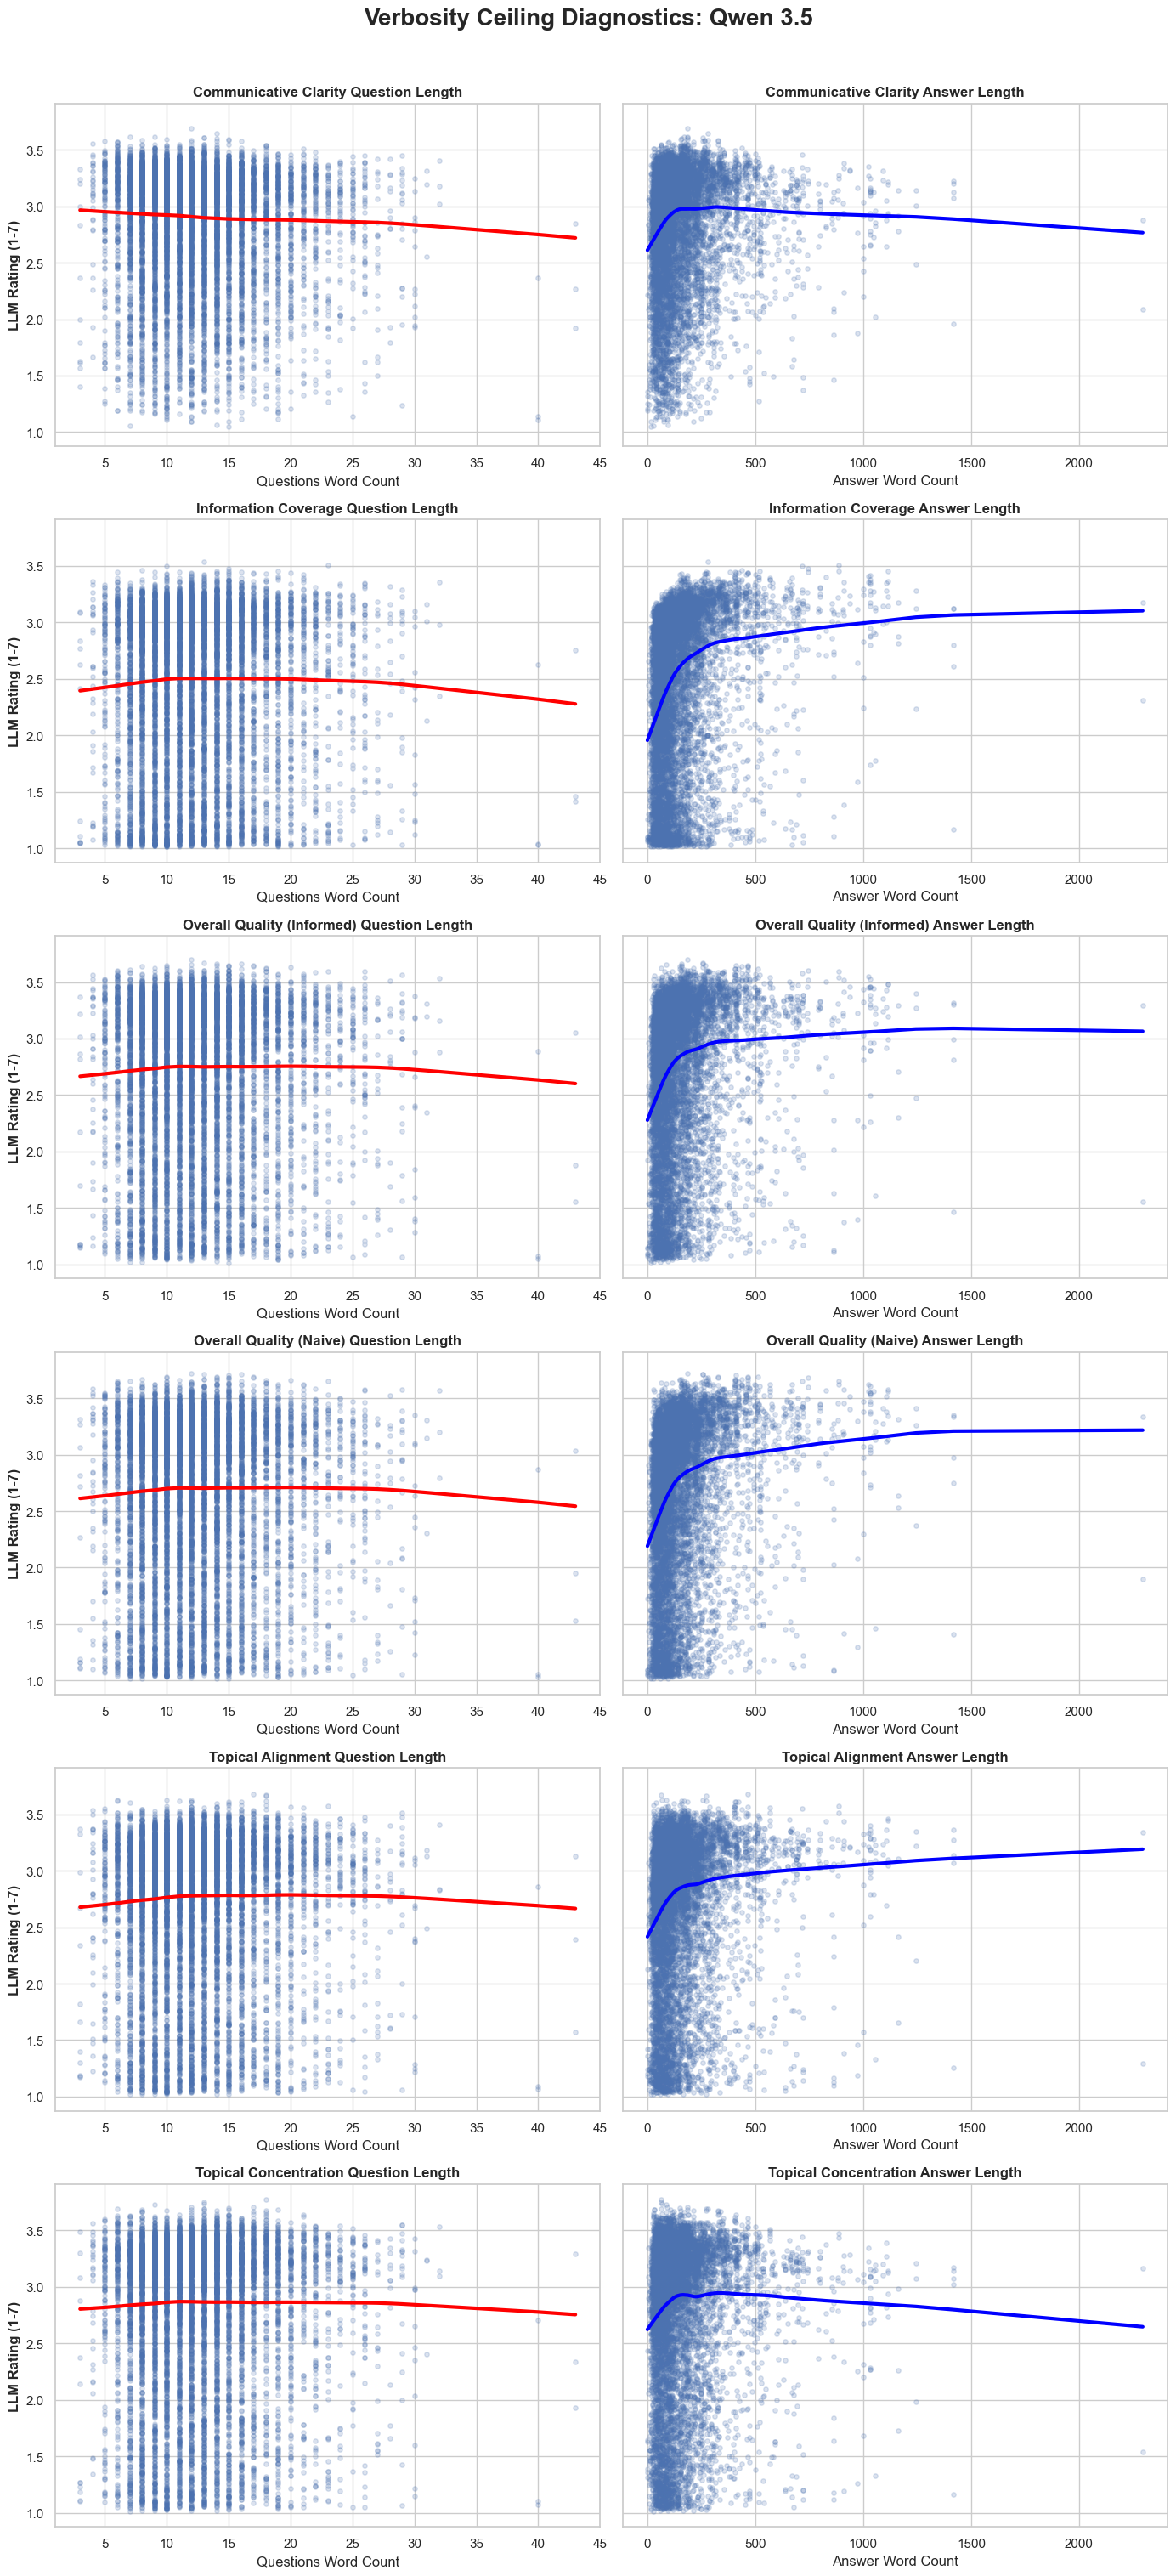

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def plot_verbosity_ceilings(df: pd.DataFrame,
                            model_name: str,
                            model_col: str = 'model_name_clean',
                            dim_col: str = 'dimension_name_clean',
                            save_path: str = None):
    """
    Generates a facet grid of LOESS curves to diagnose Verbosity Bias ceilings.
    Creates an N x 2 grid where N is the number of available dimensions.
    """
    # 1. Filter for the specific model
    subset = df[df[model_col] == model_name].copy()

    # 2. Get all unique dimensions for this model and sort them
    dimensions = sorted(subset[dim_col].dropna().unique())
    n_dims = len(dimensions)

    if n_dims == 0:
        print(
            f"⚠️ No dimensions found for model: {model_name} in column: {model_col}")
        return

    # 3. Create the Grid: n_dims rows, 2 columns
    # We give each row 5 inches of height
    fig, axes = plt.subplots(nrows=n_dims, ncols=2,
                             figsize=(14, 5 * n_dims), sharey=True)

    # Ensure axes is always a 2D array even if there is only 1 dimension
    if n_dims == 1:
        axes = [axes]

    # 4. Loop through each dimension and plot
    for i, dim in enumerate(dimensions):
        dim_data = subset[subset[dim_col] == dim]

        ax_req = axes[i][0]
        ax_body = axes[i][1]

        # --- Plot 1: Requirements (The Rules) ---
        sns.regplot(data=dim_data, x='question_word_count', y='mean_rating',
                    scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'red', 'lw': 3},
                    lowess=True, ax=ax_req)

        # Clean up the left plot
        # We replace newlines in the dimension name so it prints cleanly on one line
        clean_dim_name = str(dim).replace('\n', ' - ')
        ax_req.set_title(f"{clean_dim_name} Question Length",
                         fontweight='bold', fontsize=12)
        ax_req.set_xlabel("Questions Word Count")
        ax_req.set_ylabel("LLM Rating (1-7)", fontweight='bold')

        # --- Plot 2: Body (The Fluff) ---
        sns.regplot(data=dim_data, x='answer_word_count', y='mean_rating',
                    scatter_kws={'alpha': 0.2, 's': 15}, line_kws={'color': 'blue', 'lw': 3},
                    lowess=True, ax=ax_body)

        # Clean up the right plot
        ax_body.set_title(f"{clean_dim_name} Answer Length",
                          fontweight='bold', fontsize=12)
        ax_body.set_xlabel("Answer Word Count")
        ax_body.set_ylabel("")  # Hide Y-label on the right to reduce clutter

    # 5. Global Aesthetics
    plt.suptitle(f"Verbosity Ceiling Diagnostics: {model_name}",
                 fontsize=20, fontweight='bold', y=1.01)

    # Adjust layout so titles don't overlap with the row above them
    plt.tight_layout()

    # 6. Save or Show
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        print(f"✓ Plot saved to {save_path}")
    else:
        plt.show()

    # Example Usage
plot_verbosity_ceilings(
    df=final_df,
    model_name='Qwen 3.5',
    model_col='model_name_clean',   # Replace with your actual model column
    dim_col='dimension_name_clean'      # Replace with your actual dimension column
)

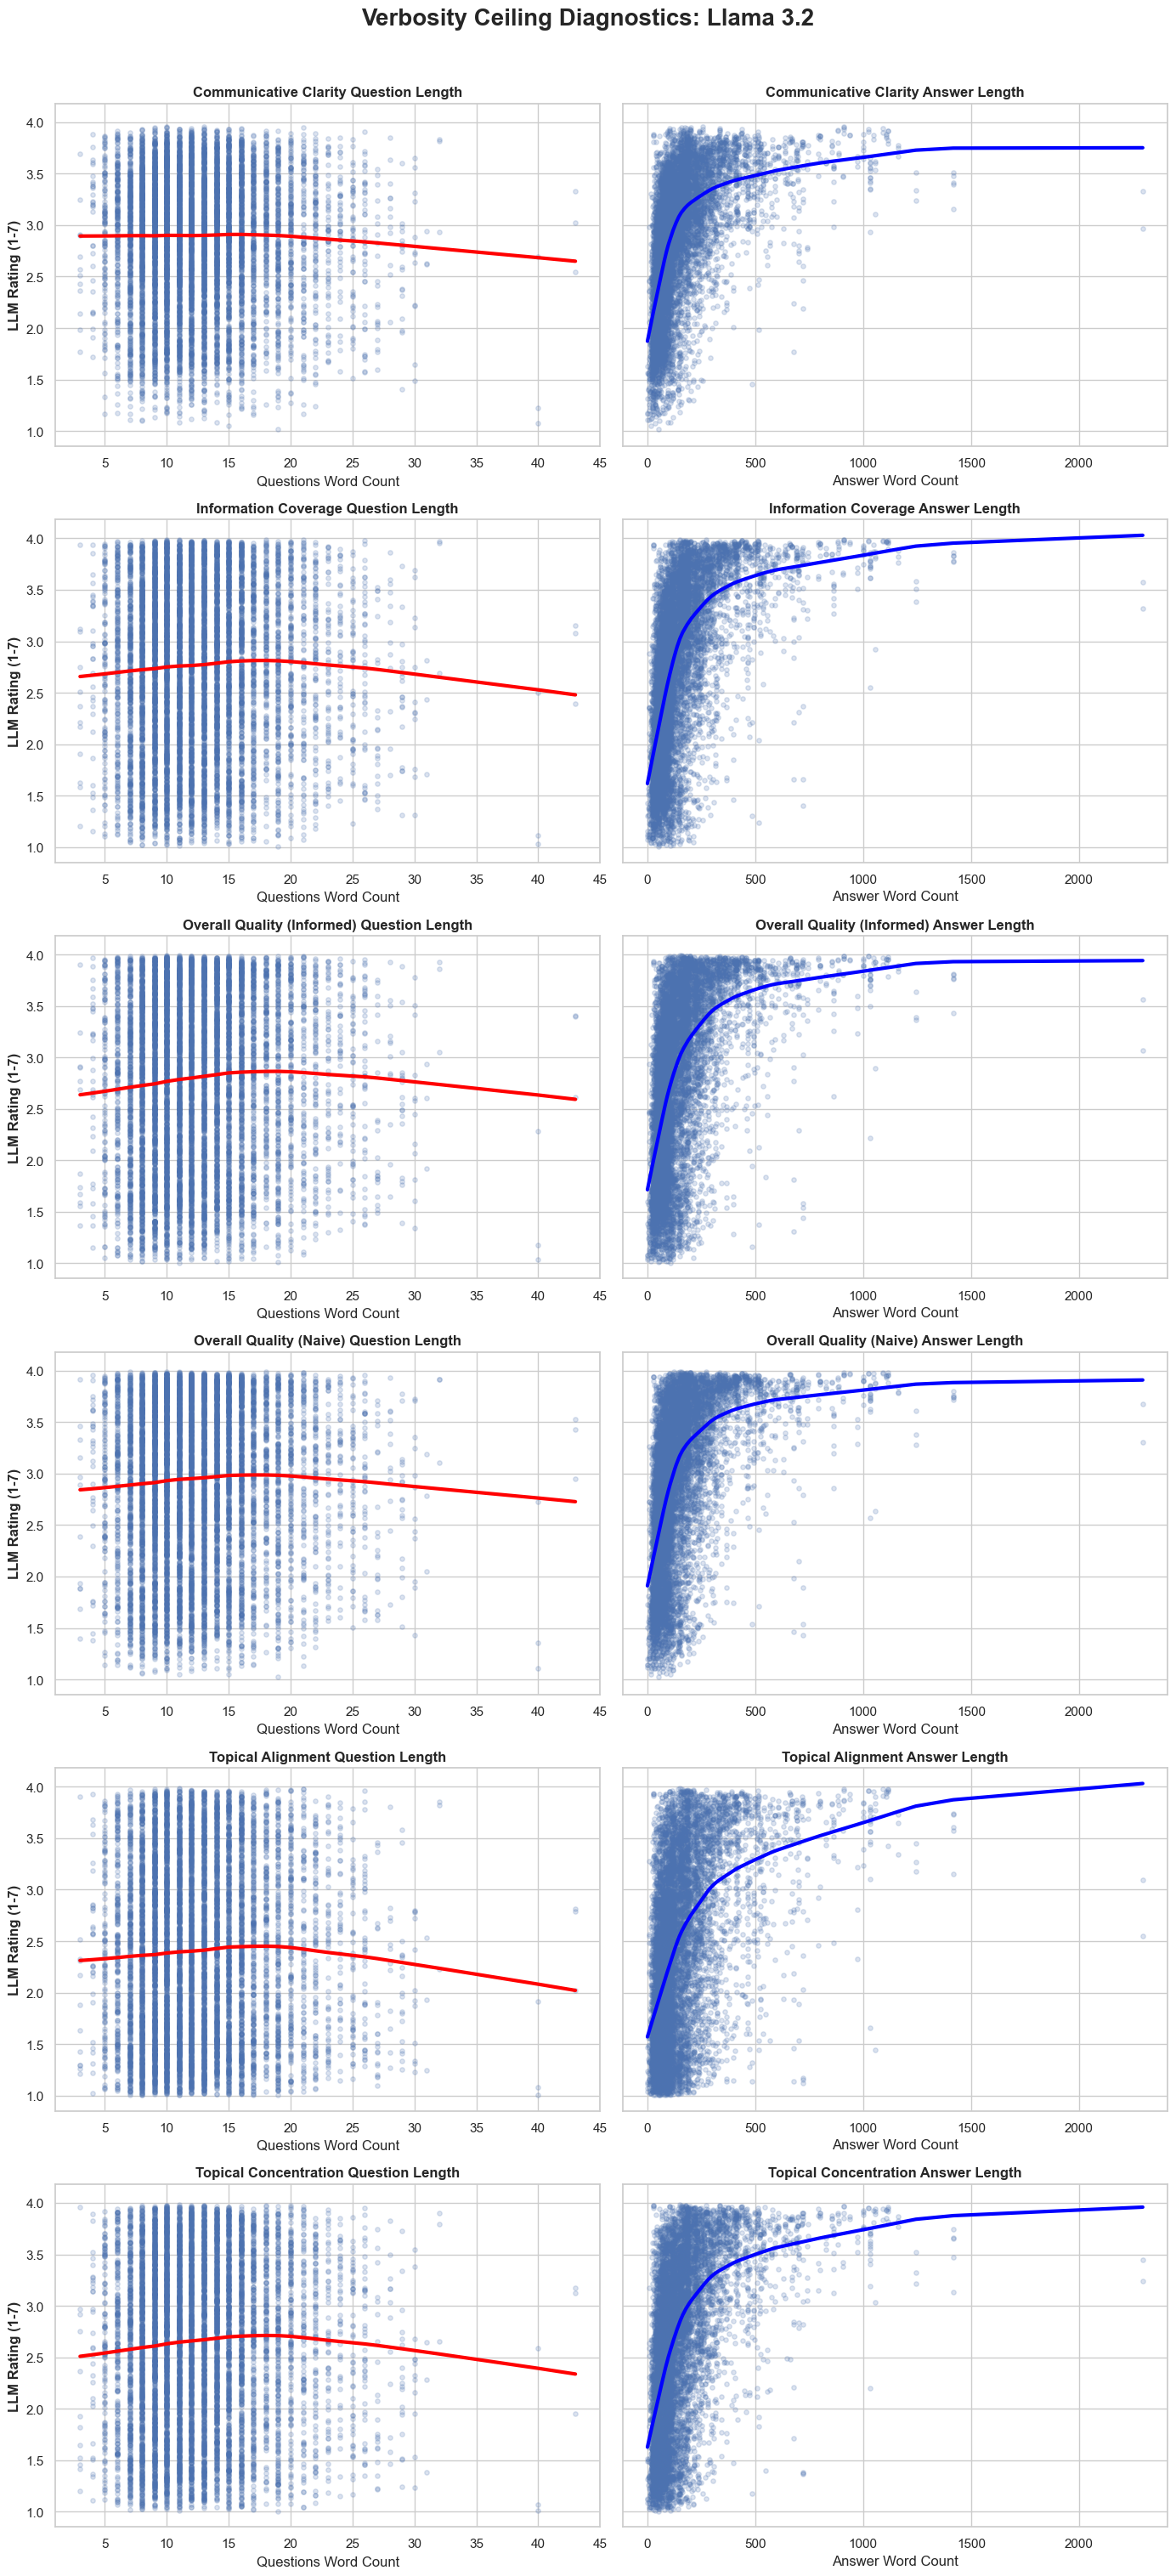

In [ ]:
# Example Usage
plot_verbosity_ceilings(
    df=final_df,
    model_name='Llama 3.2',
    model_col='model_name_clean',   # Replace with your actual model column
    dim_col='dimension_name_clean'      # Replace with your actual dimension column
)

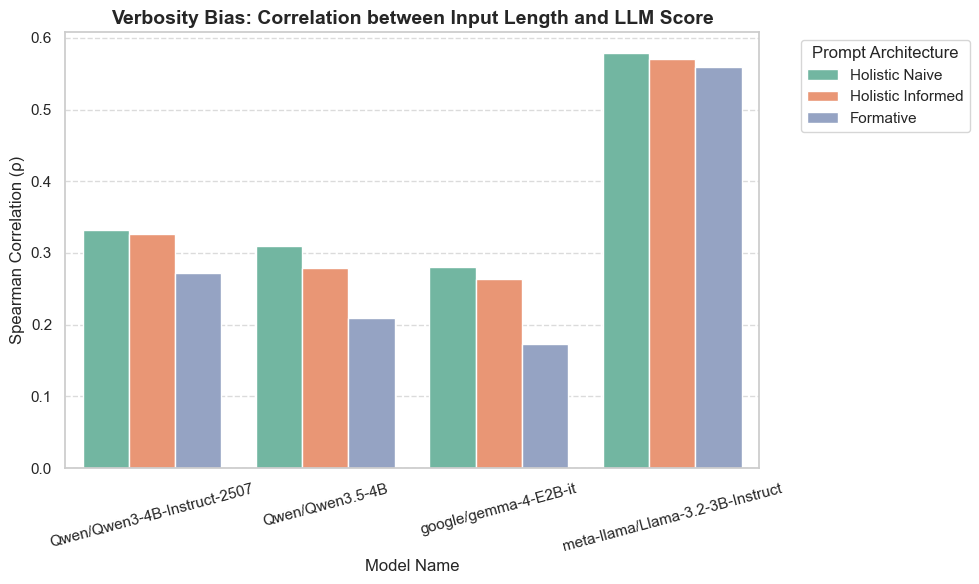

<Axes: title={'center': 'Verbosity Bias: Correlation between Input Length and LLM Score'}, xlabel='Model Name', ylabel='Spearman Correlation (ρ)'>

In [ ]:
from src.general_analysis.visualisations import plot_verbosity_bias
plot_verbosity_bias(final_df, score_column='mean_rating',
                    input_length_column='raw_input_word_count')

# Or save it
# plot_verbosity_bias(final_df, score_column='ev', save_path='figures/verbosity_bias_comparison.png')

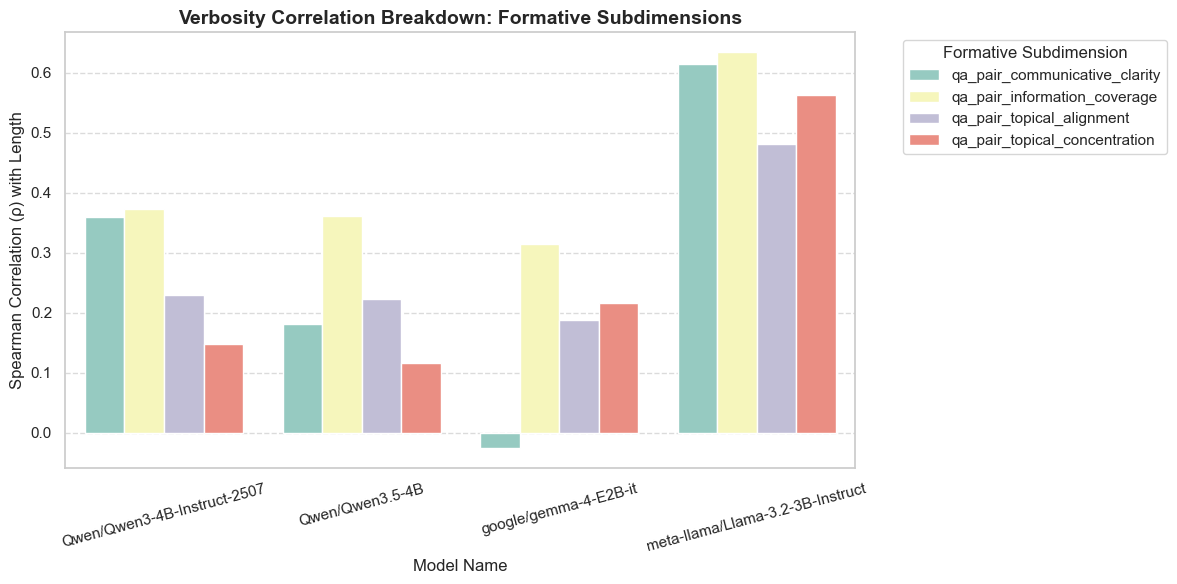

<Axes: title={'center': 'Verbosity Correlation Breakdown: Formative Subdimensions'}, xlabel='Model Name', ylabel='Spearman Correlation (ρ) with Length'>

In [ ]:
from src.general_analysis.visualisations import plot_formative_verbosity_breakdown
plot_formative_verbosity_breakdown(
    final_df, score_column='mean_rating', input_length_column='raw_input_word_count')

In [ ]:
# verbosity bias: mean_rating ~ human_rating + word_count, per (model, prompt)
# Interpretation: controlling for the human rating, how much does the LLM reward verbosity?
# That means the verbosity bias _relative to_ human verbosity bias
runner_verbosity = FeedbackQARegressionRunner(
    prompt_hash_map=prompt_hash_map,
    dep_var="mean_rating",
    covariates=["raw_input_word_count"],
    mode="verbosity",
)
runner_verbosity.run_regression(final_df)

✓ Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=18126 | AIC=41553.80
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=18126 | AIC=40717.61
✓ Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=18126 | AIC=40276.93
✓ Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=18126 | AIC=31355.56
✓ Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=18126 | AIC=31925.43
✓ Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2 | n=18126 | AIC=32359.47
✓ google/gemma-4-E2B-it_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2 | n=18126 | AIC=42066.77
✓ google/gemma-4-E2B-it_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2 | n=18126 | AIC=37082.92
✓ google/gemma-4-E2B-it_Holistic naive v2, scale 4, system p

{'Qwen/Qwen3-4B-Instruct-2507_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x26031f0d3d0>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x26033296bd0>,
 'Qwen/Qwen3-4B-Instruct-2507_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x26032002610>,
 'Qwen/Qwen3.5-4B_Formative v3, scale 4, system prompt V1, user prompt V1, rubric V2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x26031f9dc10>,
 'Qwen/Qwen3.5-4B_Holistic informed v2, scale 4, system prompt V1, user prompt V2, rubric v2': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x26033283f90>,
 'Qwen/Qwen3.5-4B_Holistic naive v2, scale 4, system prompt V1, user prompt V2': <statsmodels.regression.linear_mo

In [ ]:
interactive_regression_results_selector(runner_verbosity.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Qwen/Qwen3-4B-Instruct-2507_For…

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            mean_rating   R-squared:                       0.302
Model:                            OLS   Adj. R-squared:                  0.302
Method:                 Least Squares   F-statistic:                     2763.
Date:                Tue, 12 May 2026   Prob (F-statistic):               0.00
Time:                        23:35:30   Log-Likelihood:                -20774.
No. Observations:               18126   AIC:                         4.155e+04
Df Residuals:                   18123   BIC:                         4.158e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.9741      0.018    112.269      0.000       1.940       2.009
human_rating             0.3927      0.006     70.236      0.000       0.382       0.404
raw_input_word_count     0.0003   5.77e-05      5.356      0.000       0.000       0.000
==============================================================================
Omnibus:                      315.971   Durbin-Watson:                   1.713
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              327.448
Skew:                          -0.320   Prob(JB):                     7.86e-72
Kurtosis:                       2.846   Cond. No.                         549.
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""